In [1]:
"""
Credit Card Fraud Detection — Machine Learning Pipeline.
Detecção de Fraude em Cartão de Crédito — Pipeline de Machine Learning.
"""
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (20.5, 10)

In [2]:
"""
Load dataset and initial exploration.
Carrega dataset e exploração inicial.
"""

# LOAD DATASET / CARREGA DATASET
df = pd.read_csv(r"/content/train1 (1).csv")

# INITIAL INSPECTION / INSPEÇÃO INICIAL
df.head()

,Ref.No,X1,X2,X3,X4,X5,X6,X7,Y
0,22203,320000,2,1,2,27,1,2,1
1,1288,470000,1,2,1,41,-2,-2,0
2,11822,20000,1,2,2,25,1,2,0
3,15085,80000,1,3,1,41,0,0,1
4,6192,30000,1,1,2,30,1,-2,1


In [3]:
df.tail()

,Ref.No,X1,X2,X3,X4,X5,X6,X7,Y
21595,7650,150000,1,2,1,39,-1,-1,0
21596,15207,70000,2,3,2,29,0,-1,0
21597,5471,140000,1,2,2,27,0,0,0
21598,6855,180000,1,1,1,35,1,2,1
21599,2673,30000,2,2,2,41,0,-1,0


In [4]:
df.shape

(21600, 9)

In [5]:
df.dtypes

,0
Ref.No,int64
X1,int64
X2,int64
X3,int64
X4,int64
X5,int64
X6,int64
X7,int64
Y,int64


In [6]:
df.isnull().sum()

,0
Ref.No,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
Y,0


Non-fraud transactions / Transações sem fraude: 16766 (77.62%)
Fraud transactions / Transações com fraude:     4834 (22.38%)


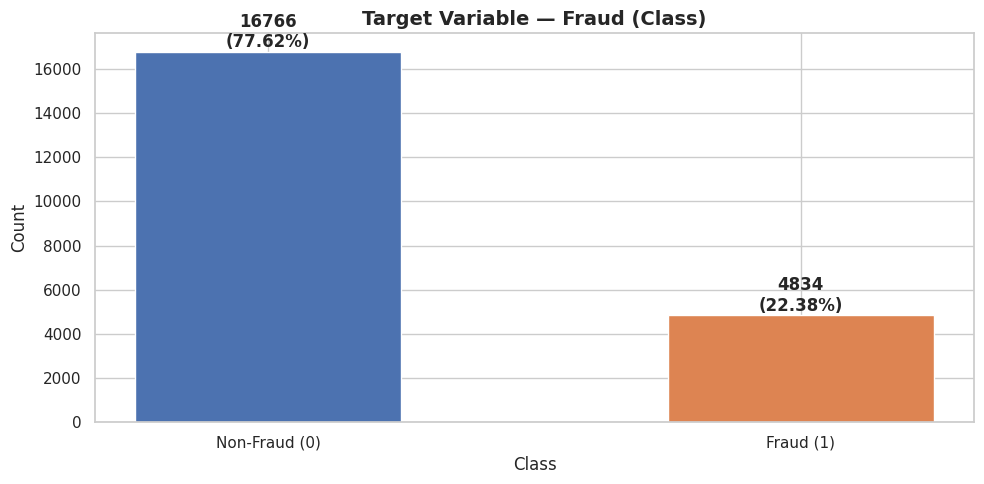

In [7]:
"""
Target variable analysis — fraud vs non-fraud distribution.
Análise da variável alvo — distribuição fraude vs não-fraude.
"""

# COUNT AND PERCENTAGE / CONTAGEM E PERCENTUAL
fraud_counts = df["Y"].value_counts()
fraud_pct    = df["Y"].value_counts(normalize=True) * 100

print(f"Non-fraud transactions / Transações sem fraude: {fraud_counts[0]} ({fraud_pct[0]:.2f}%)")
print(f"Fraud transactions / Transações com fraude:     {fraud_counts[1]} ({fraud_pct[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    ["Non-Fraud (0)", "Fraud (1)"],
    fraud_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5
)
ax.set_title("Target Variable — Fraud (Class)", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 200, f"{v}\n({fraud_pct.iloc[i]:.2f}%)", ha="center", fontweight="bold")

plt.tight_layout()
#plt.savefig("img/01_target_variable.png", dpi=150, bbox_inches="tight")
#plt.show()

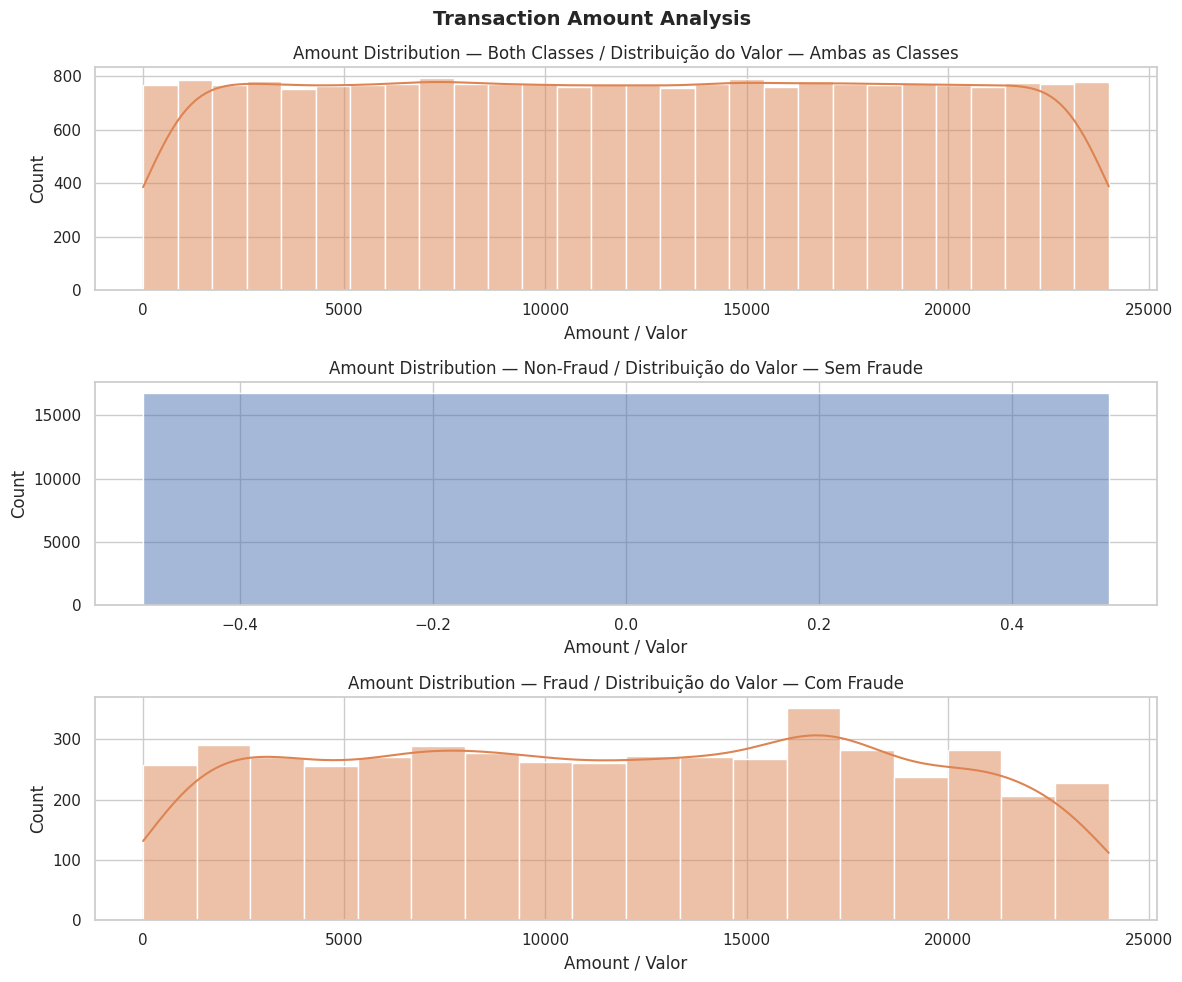

In [8]:
"""
Transaction amount and time distribution analysis.
Análise da distribuição de valor e tempo das transações.
"""

# AMOUNT DISTRIBUTION / DISTRIBUIÇÃO DO VALOR
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

sns.histplot(df["Ref.No"], ax=axes[0], color="#DD8452", kde=True)
axes[0].set_title("Amount Distribution — Both Classes / Distribuição do Valor — Ambas as Classes", fontsize=12)
axes[0].set_xlabel("Amount / Valor")

sns.histplot(df[df["Y"] == 0]["Y"], ax=axes[1], color="#4C72B0", kde=True)
axes[1].set_title("Amount Distribution — Non-Fraud / Distribuição do Valor — Sem Fraude", fontsize=12)
axes[1].set_xlabel("Amount / Valor")

sns.histplot(df[df["Y"] == 1]["Ref.No"], ax=axes[2], color="#DD8452", kde=True)
axes[2].set_title("Amount Distribution — Fraud / Distribuição do Valor — Com Fraude", fontsize=12)
axes[2].set_xlabel("Amount / Valor")

plt.suptitle("Transaction Amount Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("img/02_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

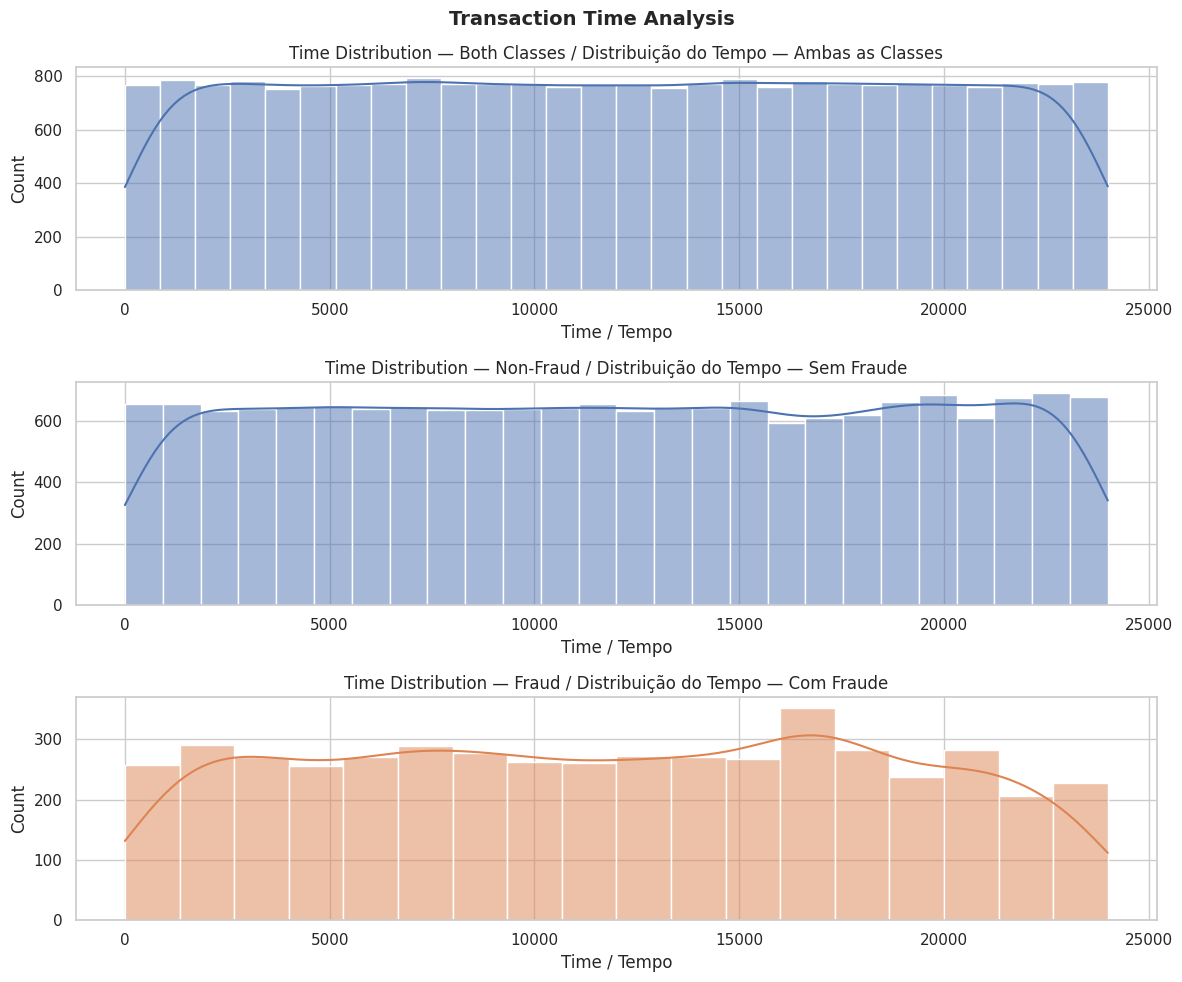

In [9]:
"""
Time distribution analysis by class.
Análise da distribuição de tempo por classe.
"""

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

sns.histplot(df["Ref.No"], ax=axes[0], color="#4C72B0", kde=True)
axes[0].set_title("Time Distribution — Both Classes / Distribuição do Tempo — Ambas as Classes", fontsize=12)
axes[0].set_xlabel("Time / Tempo")

sns.histplot(df[df["Y"] == 0]["Ref.No"], ax=axes[1], color="#4C72B0", kde=True)
axes[1].set_title("Time Distribution — Non-Fraud / Distribuição do Tempo — Sem Fraude", fontsize=12)
axes[1].set_xlabel("Time / Tempo")

sns.histplot(df[df["Y"] == 1]["Ref.No"], ax=axes[2], color="#DD8452", kde=True)
axes[2].set_title("Time Distribution — Fraud / Distribuição do Tempo — Com Fraude", fontsize=12)
axes[2].set_xlabel("Time / Tempo")

plt.suptitle("Transaction Time Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("img/03_time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
"""
Feature scaling using RobustScaler for Amount and Time.
Escalonamento de features usando RobustScaler para Amount e Time.
"""

from sklearn.preprocessing import RobustScaler

# ROBUST SCALER — LESS SENSITIVE TO OUTLIERS / MENOS SENSÍVEL A OUTLIERS
robust_scaler = RobustScaler()

df["X1"] = robust_scaler.fit_transform(df["X1"].values.reshape(-1, 1))
df["Ref.No"]   = robust_scaler.fit_transform(df["Ref.No"].values.reshape(-1, 1))

print("Scaling complete / Escalonamento concluído:")
print(df[["X1", "Ref.No"]].describe().round(4))

Scaling complete / Escalonamento concluído:
               X1      Ref.No
count  21600.0000  21600.0000
mean       0.1402     -0.0001
std        0.7167      0.5783
min       -0.7222     -1.0012
25%       -0.5000     -0.5000
50%        0.0000      0.0000
75%        0.5000      0.5000
max        4.7778      1.0010


In [11]:
"""
Train test split using StratifiedKFold to preserve class proportions.
Divisão treino teste usando StratifiedKFold para preservar proporções das classes.
"""

from sklearn.model_selection import StratifiedKFold, train_test_split

X = df.drop(columns=["Y"])
y = df["Y"]

# STRATIFIED KFOLD / KFOLD ESTRATIFICADO
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in strat_kfold.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

X_train = X_train.values
X_test  = X_test.values
y_train = y_train.values
y_test  = y_test.values

print(f"Train size / Tamanho treino: {X_train.shape[0]}")
print(f"Test size / Tamanho teste:   {X_test.shape[0]}")

Train size / Tamanho treino: 17280
Test size / Tamanho teste:   4320


In [12]:
# CLASS DISTRIBUTION / DISTRIBUIÇÃO DAS CLASSES
import numpy as np
labels_train, counts_train = np.unique(y_train, return_counts=True)
labels_test,  counts_test  = np.unique(y_test,  return_counts=True)
print(f"\nTrain class distribution / Distribuição treino: {counts_train / len(y_train)}")
print(f"Test class distribution / Distribuição teste:   {counts_test  / len(y_test)}")


Train class distribution / Distribuição treino: [0.77615741 0.22384259]
Test class distribution / Distribuição teste:   [0.77638889 0.22361111]


Balanced dataset / Dataset balanceado: {0: 4834, 1: 4834}


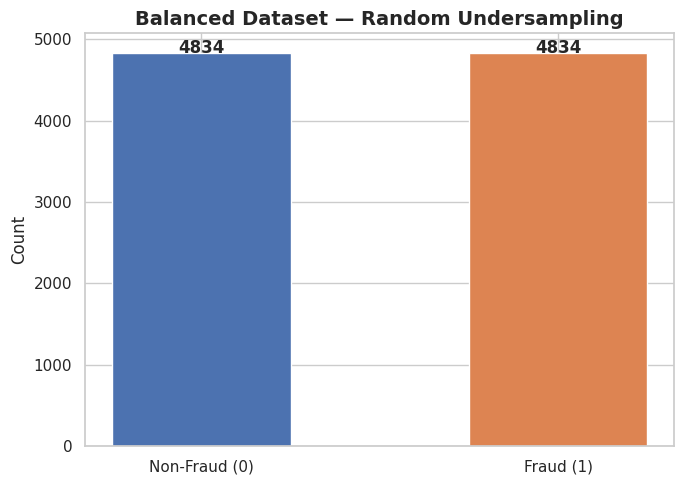

In [13]:
"""
Random undersampling to balance classes for initial analysis.
Subamostragem aleatória para balancear classes para análise inicial.
"""

# RANDOM UNDERSAMPLING / SUBAMOSTRAGEM ALEATÓRIA
df_shuffled  = df.sample(frac=1, random_state=42)
fraud_df     = df_shuffled[df_shuffled["Y"] == 1]
non_fraud_df = df_shuffled[df_shuffled["Y"] == 0][:len(fraud_df)]
df_balanced  = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42)

print(f"Balanced dataset / Dataset balanceado: {df_balanced['Y'].value_counts().to_dict()}")

# PLOT BALANCED DISTRIBUTION / PLOTA DISTRIBUIÇÃO BALANCEADA
fig, ax = plt.subplots(figsize=(7, 5))
bal_counts = df_balanced["Y"].value_counts()
ax.bar(
    ["Non-Fraud (0)", "Fraud (1)"],
    bal_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5
)
ax.set_title("Balanced Dataset — Random Undersampling", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
for i, v in enumerate(bal_counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")

plt.tight_layout()
#plt.savefig("img/04_balanced_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

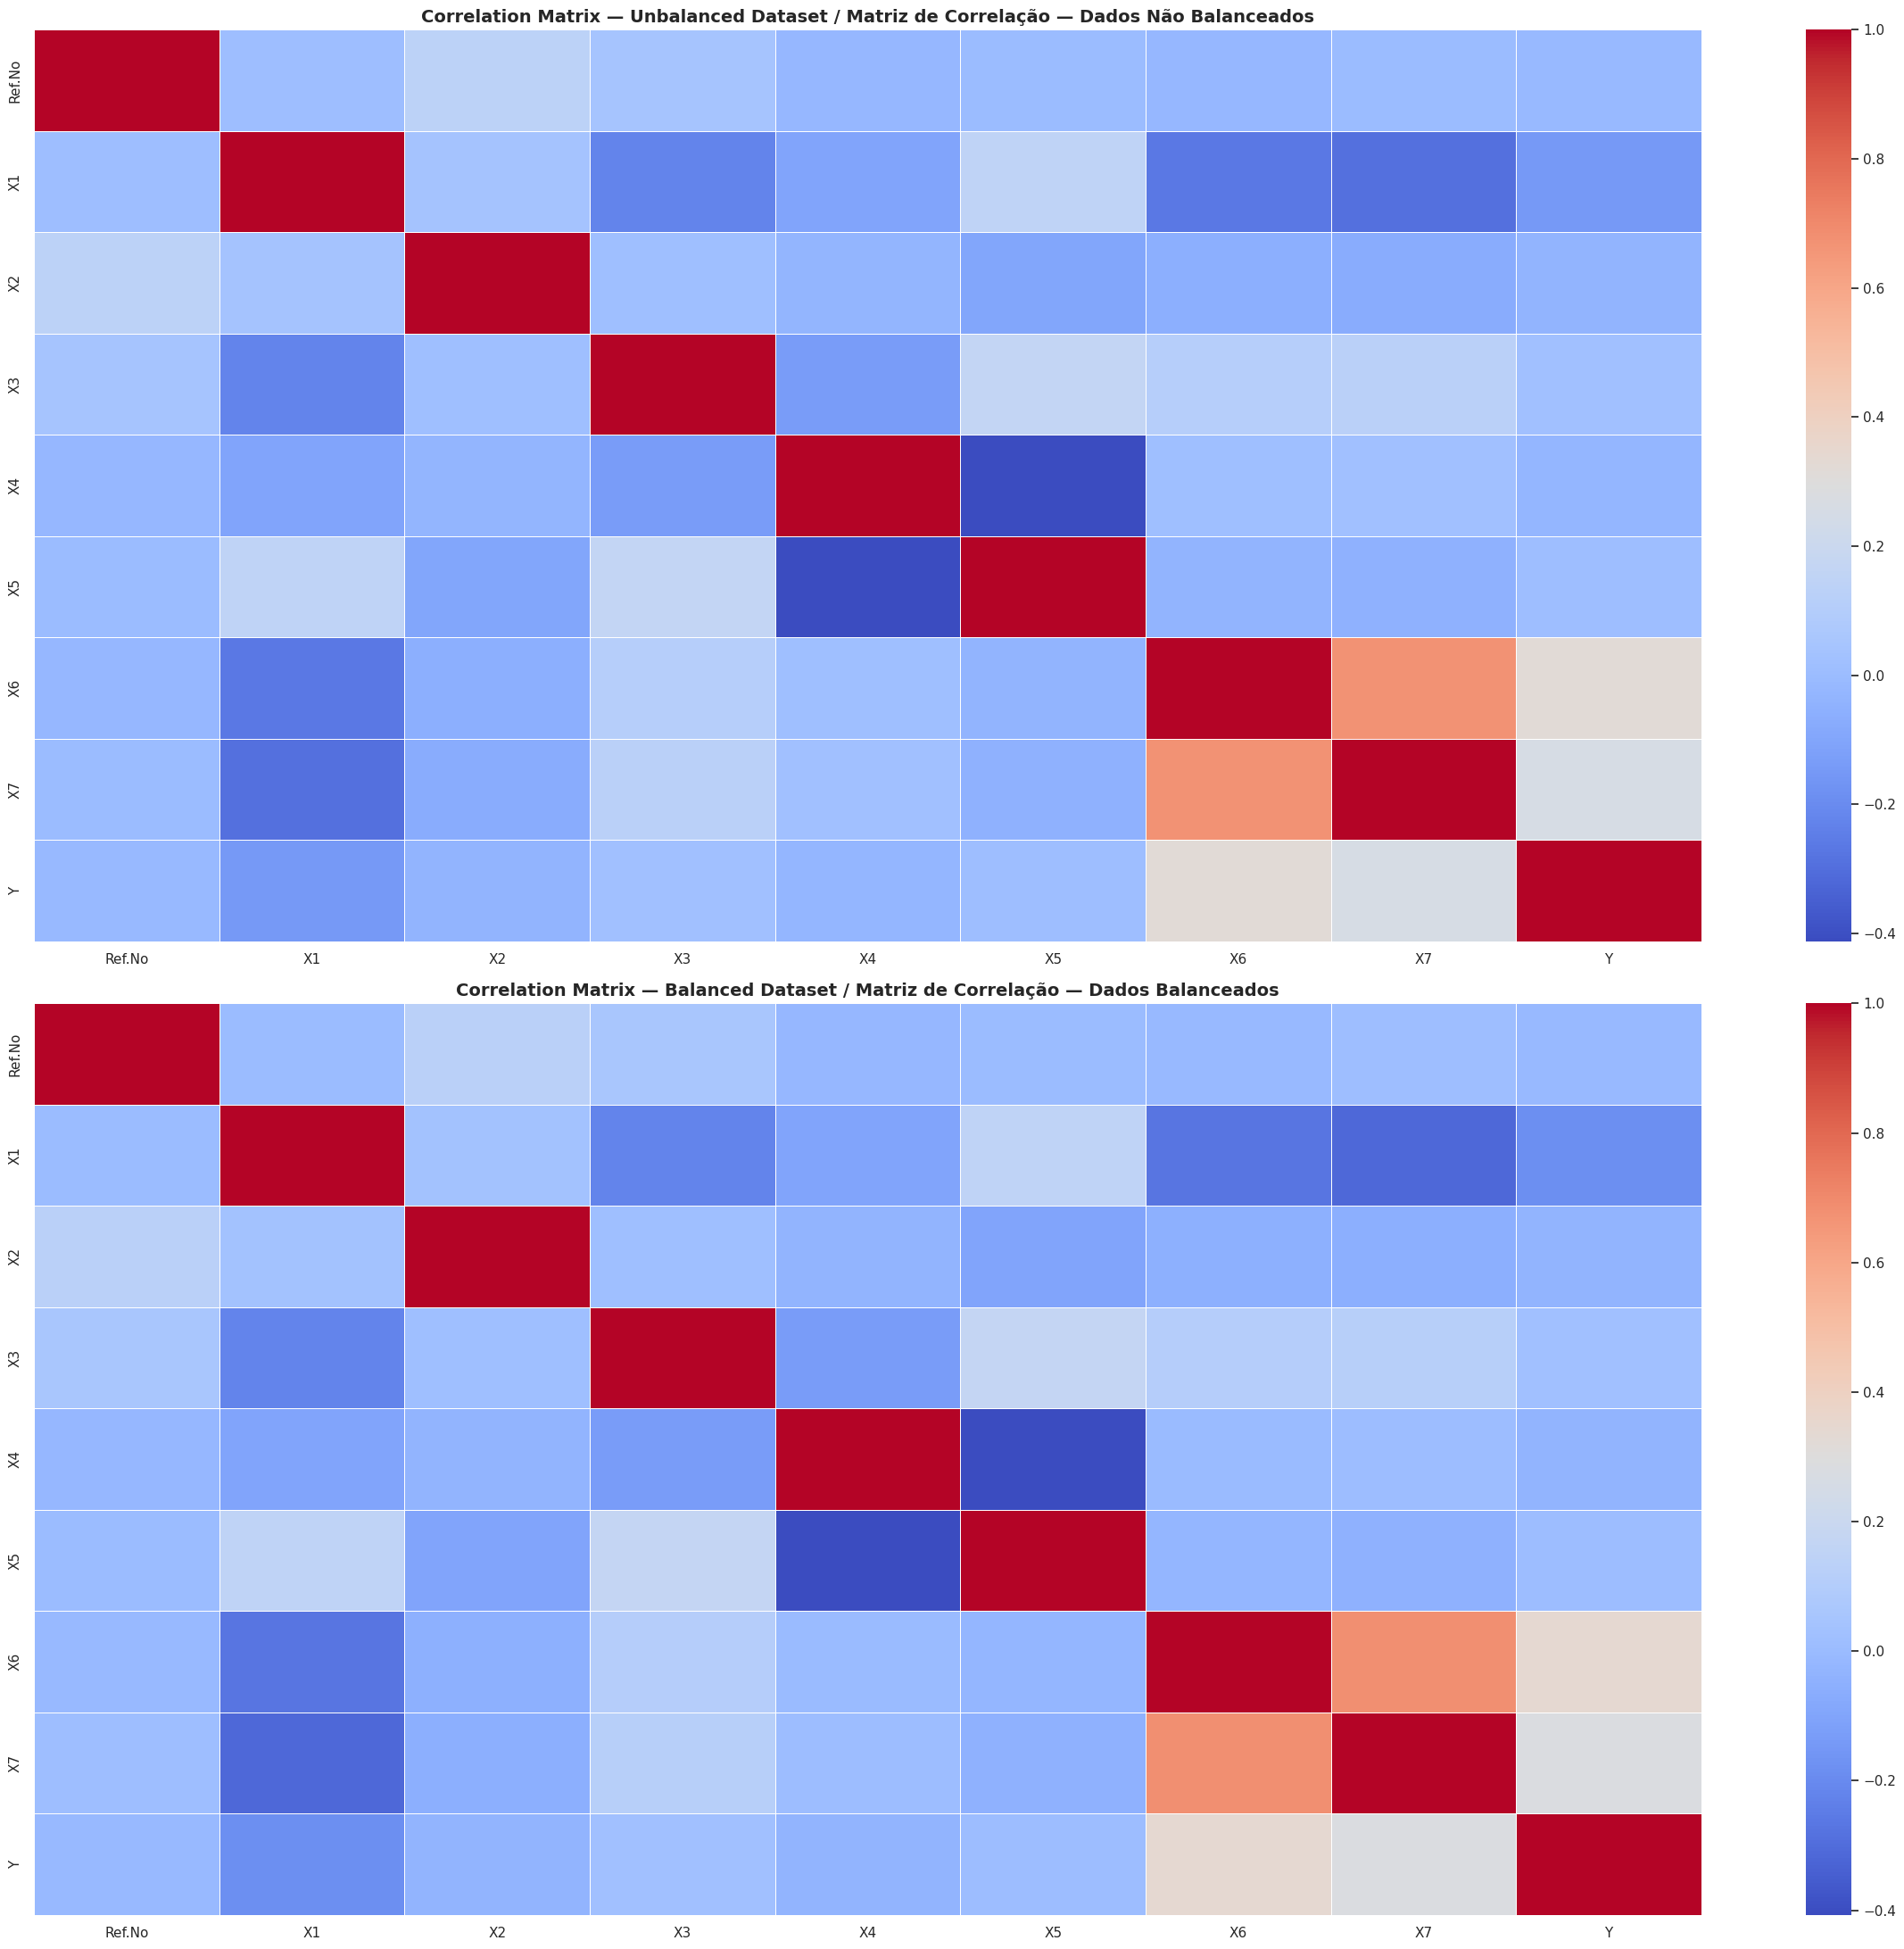

In [14]:
"""
Correlation matrix — balanced vs unbalanced dataset.
Matriz de correlação — dataset balanceado vs não balanceado.
"""

corr_unbalanced = df.corr()
corr_balanced   = df_balanced.corr()

fig, axes = plt.subplots(2, 1, figsize=(24, 22))

sns.heatmap(corr_unbalanced, cmap="coolwarm", annot=False, ax=axes[0], linewidths=0.5)
axes[0].set_title("Correlation Matrix — Unbalanced Dataset / Matriz de Correlação — Dados Não Balanceados", fontsize=14, fontweight="bold")

sns.heatmap(corr_balanced, cmap="coolwarm", annot=False, ax=axes[1], linewidths=0.5)
axes[1].set_title("Correlation Matrix — Balanced Dataset / Matriz de Correlação — Dados Balanceados", fontsize=14, fontweight="bold")

plt.tight_layout()
#plt.savefig("img/05_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

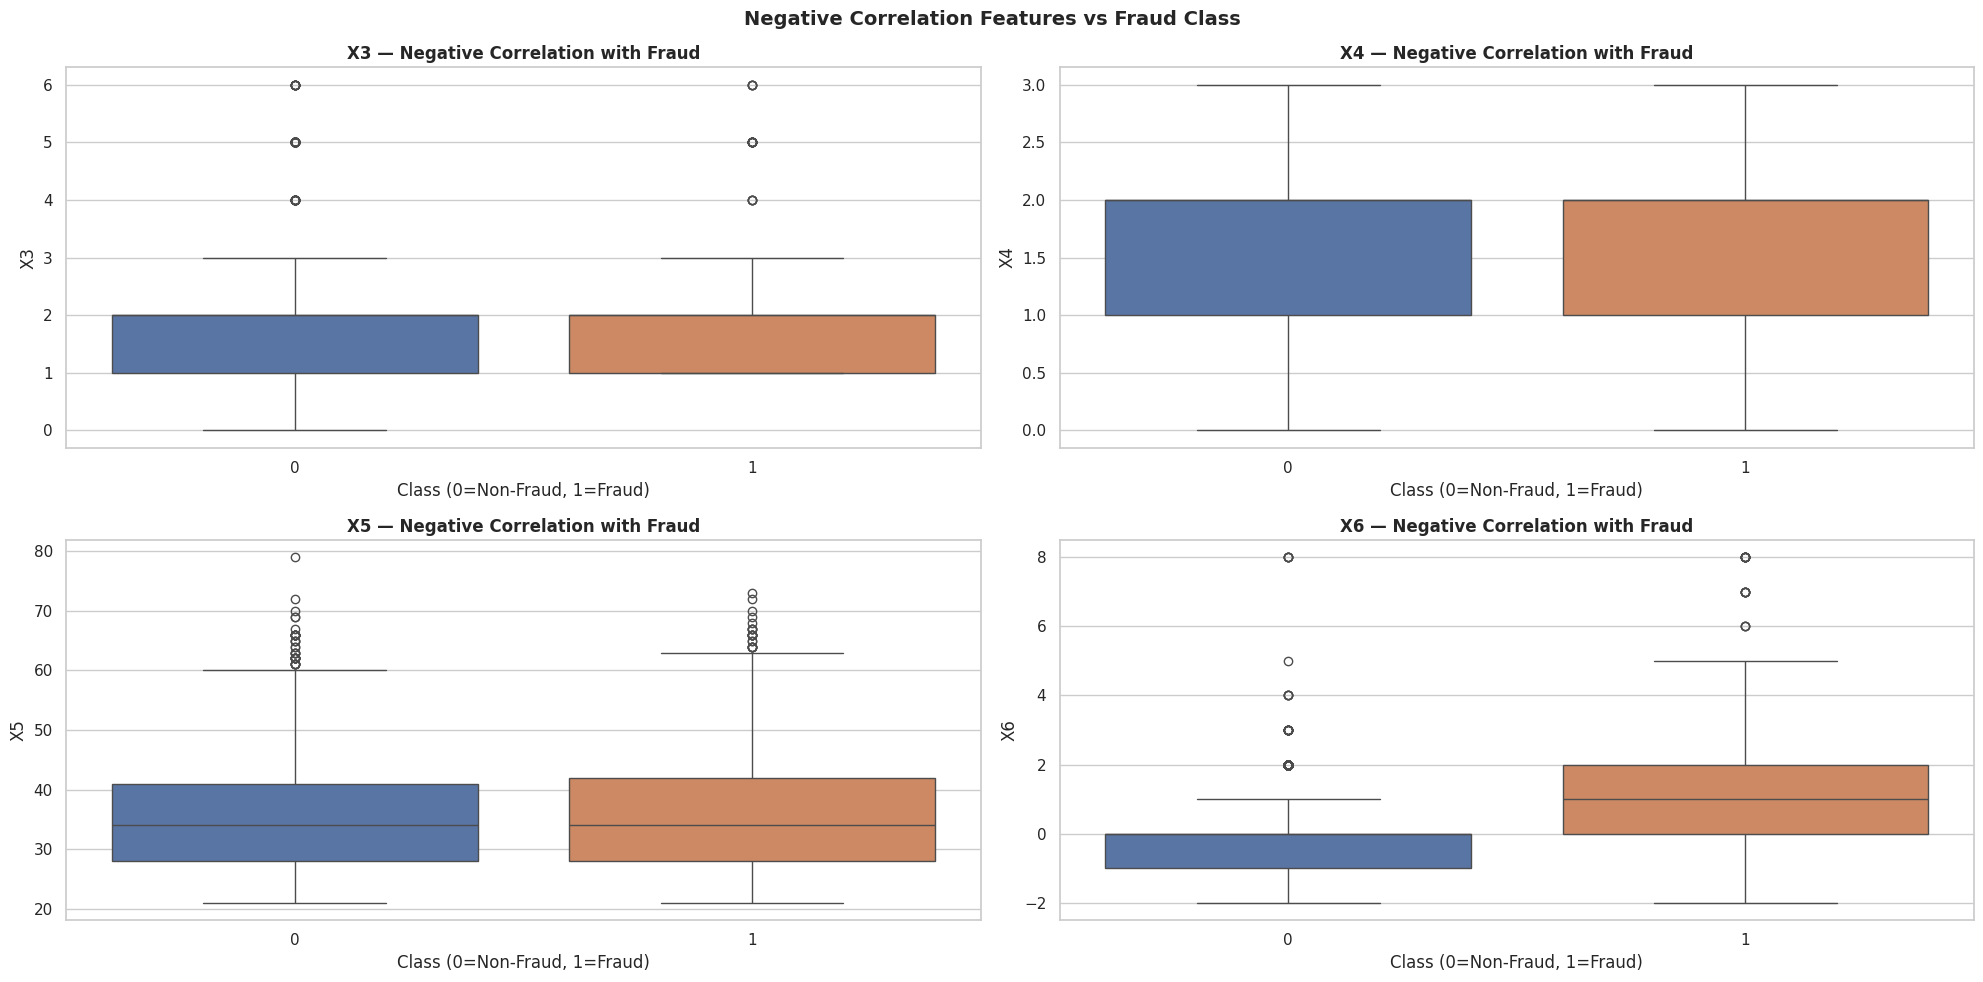

In [15]:
"""
Boxplot analysis for most correlated features with fraud class.
Análise de boxplot para features mais correlacionadas com a classe fraude.
"""

# NEGATIVE CORRELATION FEATURES / FEATURES DE CORRELAÇÃO NEGATIVA
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

for ax, col in zip(axes.flatten(), ["X3", "X4", "X5", "X6"]):
    sns.boxplot(x="Y", y=col, data=df_balanced, palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(f"{col} — Negative Correlation with Fraud", fontsize=12, fontweight="bold")
    ax.set_xlabel("Class (0=Non-Fraud, 1=Fraud)")

plt.suptitle("Negative Correlation Features vs Fraud Class", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("img/06_boxplot_negative.png", dpi=150, bbox_inches="tight")
plt.show()

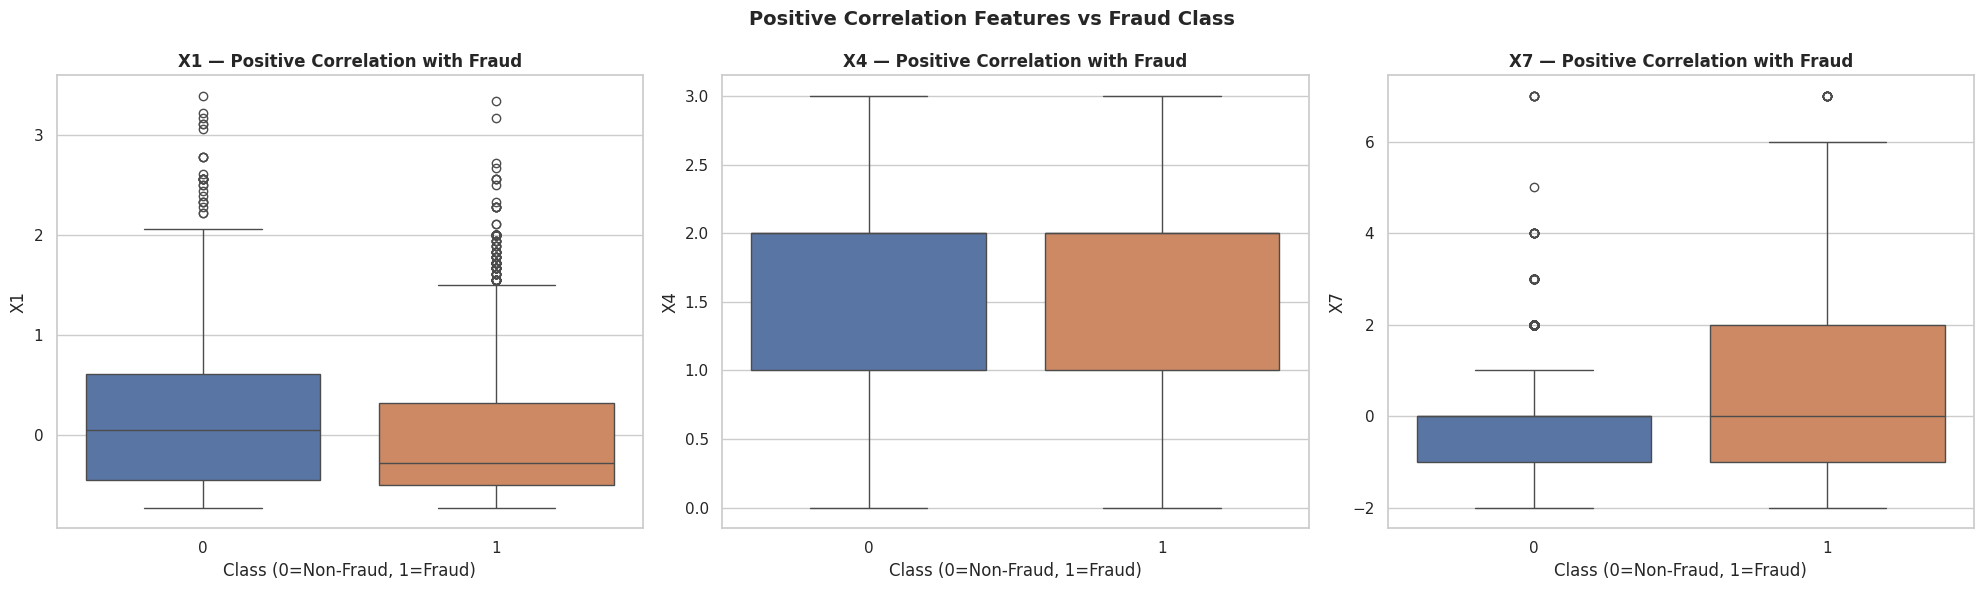

In [16]:
# POSITIVE CORRELATION FEATURES / FEATURES DE CORRELAÇÃO POSITIVA
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes.flatten(), ["X1", "X4", "X7"]):
    sns.boxplot(x="Y", y=col, data=df_balanced, palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(f"{col} — Positive Correlation with Fraud", fontsize=12, fontweight="bold")
    ax.set_xlabel("Class (0=Non-Fraud, 1=Fraud)")

plt.suptitle("Positive Correlation Features vs Fraud Class", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("img/07_boxplot_positive.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
"""
Outlier removal using IQR method on fraud class for key features.
Remoção de outliers usando método IQR na classe fraude para features principais.
"""

def remove_outliers_iqr(dataframe, column):
    """Remove outliers using IQR method / Remove outliers usando método IQR."""
    fraud_vals      = dataframe[column][dataframe["Y"] == 1].values
    q25, q75        = np.percentile(fraud_vals, 25), np.percentile(fraud_vals, 75)
    iqr             = q75 - q25
    cut_off         = iqr * 1.5
    lower, upper    = q25 - cut_off, q75 + cut_off
    outliers        = [x for x in fraud_vals if x < lower or x > upper]
    print(f"{column} — Outliers removed / removidos: {len(outliers)} | Lower: {lower:.4f} | Upper: {upper:.4f}")
    return dataframe.drop(dataframe[(dataframe[column] > upper) | (dataframe[column] < lower)].index)

# APPLY IQR REMOVAL / APLICA REMOÇÃO IQR
for col in ["X1", "X4", "X7"]:
    df_balanced = remove_outliers_iqr(df_balanced, col)

print(f"\nDataset shape after outlier removal / Após remoção de outliers: {df_balanced.shape}")

X1 — Outliers removed / removidos: 148 | Lower: -1.7292 | Upper: 1.5486
X4 — Outliers removed / removidos: 0 | Lower: -0.5000 | Upper: 3.5000
X7 — Outliers removed / removidos: 17 | Lower: -3.0000 | Upper: 5.0000

Dataset shape after outlier removal / Após remoção de outliers: (9192, 9)


Fitting reduction models / Ajustando modelos de redução: 100%|██████████| 3/3 [01:47<00:00, 35.73s/model] 
Plotting / Plotando: 100%|██████████| 3/3 [00:00<00:00, 65.35plot/s]


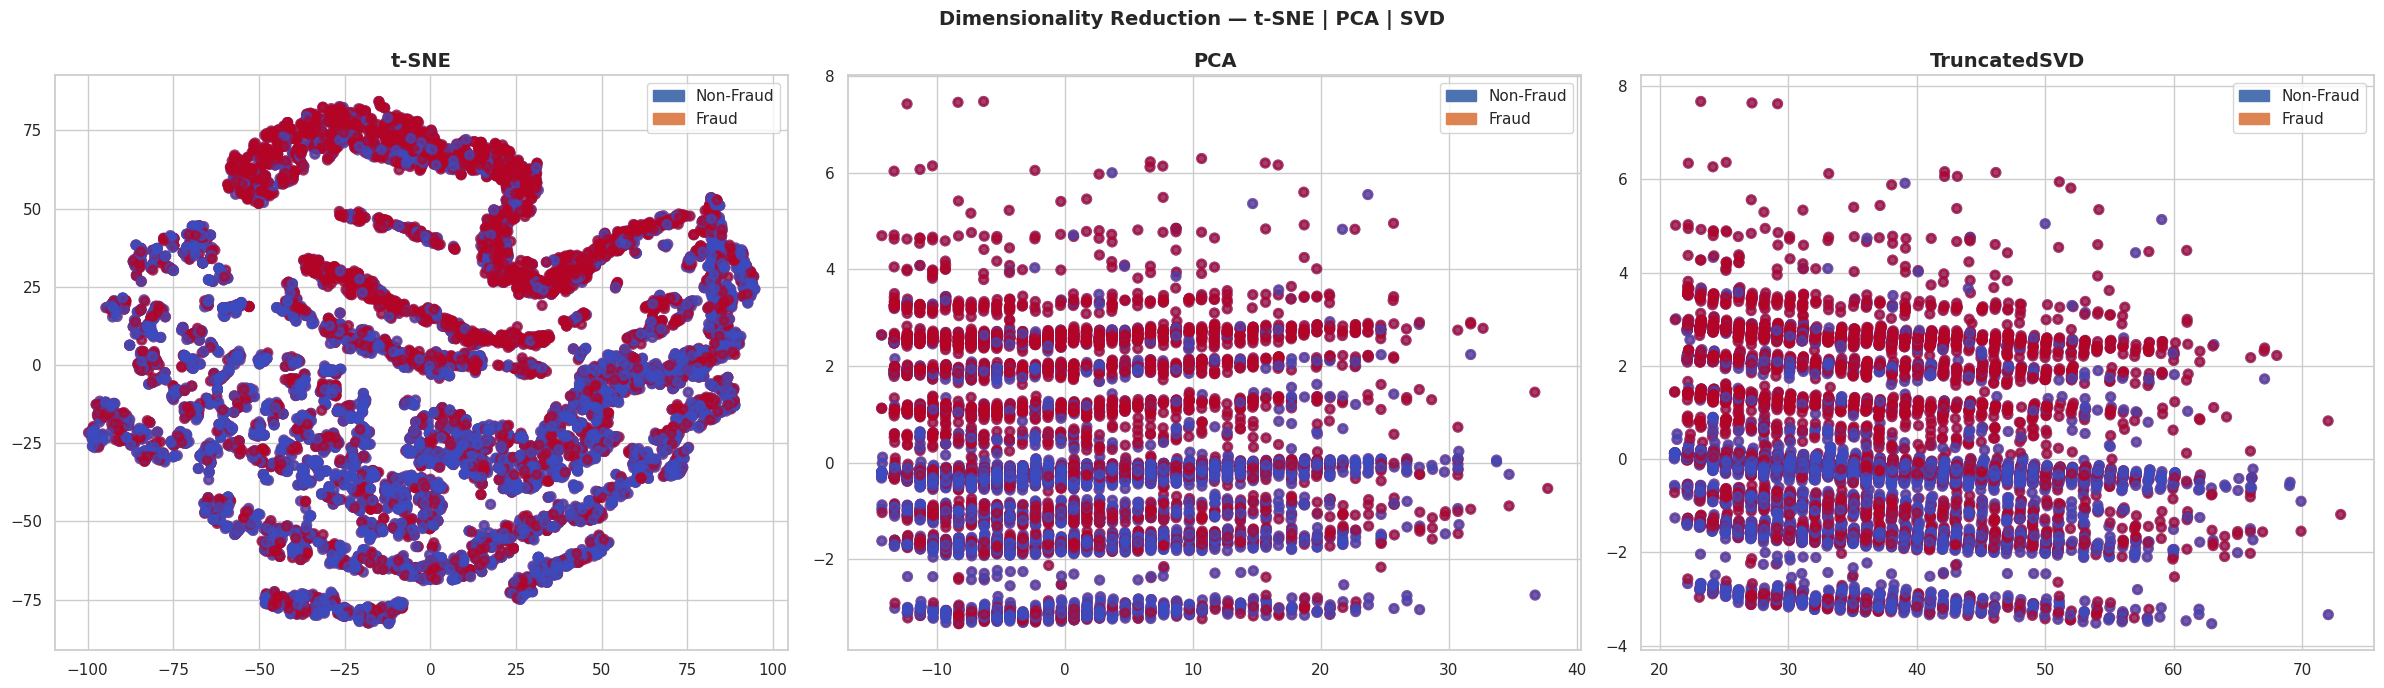

In [18]:
"""
Dimensionality reduction using t-SNE, PCA and TruncatedSVD with progress bar.
Redução de dimensionalidade usando t-SNE, PCA e TruncatedSVD com barra de progresso.
"""

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
from tqdm import tqdm
import time

X_vis = df_balanced.drop("Y", axis=1).values
y_vis = df_balanced["Y"].values

# DIMENSIONALITY REDUCTION MODELS / MODELOS DE REDUÇÃO DE DIMENSIONALIDADE
reduction_models = {
    "t-SNE":        TSNE(n_components=2, random_state=42),
    "PCA":          PCA(n_components=2, random_state=42),
    "TruncatedSVD": TruncatedSVD(n_components=2, algorithm="randomized", random_state=42),
}

# STORE RESULTS / ARMAZENA RESULTADOS
X_reduced = {}

for name, model in tqdm(reduction_models.items(), desc="Fitting reduction models / Ajustando modelos de redução", unit="model"):
    X_reduced[name] = model.fit_transform(X_vis)

# PLOT RESULTS / PLOTA RESULTADOS
blue_patch = mpatches.Patch(color="#4C72B0", label="Non-Fraud")
red_patch  = mpatches.Patch(color="#DD8452", label="Fraud")

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (title, X_red) in tqdm(
    zip(axes, X_reduced.items()),
    desc="Plotting / Plotando",
    total=len(X_reduced),
    unit="plot"
):
    ax.scatter(X_red[:, 0], X_red[:, 1], c=(y_vis == 0), cmap="coolwarm", linewidths=2, alpha=0.6)
    ax.scatter(X_red[:, 0], X_red[:, 1], c=(y_vis == 1), cmap="coolwarm", linewidths=2, alpha=0.6)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True)
    ax.legend(handles=[blue_patch, red_patch])

plt.suptitle("Dimensionality Reduction — t-SNE | PCA | SVD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
"""
Train test split for balanced dataset model training.
Divisão treino teste para treinamento dos modelos no dataset balanceado.
"""

from sklearn.model_selection import train_test_split

X_bal = df_balanced.drop("Y", axis=1).values
y_bal = df_balanced["Y"].values

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

print(f"Train size / Tamanho treino: {X_train_bal.shape[0]}")
print(f"Test size / Tamanho teste:   {X_test_bal.shape[0]}")

Train size / Tamanho treino: 7353
Test size / Tamanho teste:   1839


# **Secção A) Machine learning**

In [20]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [21]:
%%time

"""
Train all machine learning models and evaluate with cross-validation.
Treina todos os modelos de machine learning e avalia com validação cruzada.
"""

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm

# DEFINE ALL MODELS / DEFINE TODOS OS MODELOS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN":                 KNeighborsClassifier(),
    "SVC":                 SVC(random_state=42, probability=True),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "AdaBoost":            AdaBoostClassifier(random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    "LightGBM":            LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost":            CatBoostClassifier(random_state=42, verbose=0),
}

# TRAIN AND EVALUATE WITH PROGRESS BAR / TREINA E AVALIA COM BARRA DE PROGRESSO
results = []

pbar = tqdm(models.items(), total=len(models), desc="Training models / Treinando modelos", unit="model")

for name, model in pbar:

    # UPDATE PROGRESS BAR DESCRIPTION / ATUALIZA DESCRIÇÃO DA BARRA
    pbar.set_description(f"Training / Treinando: {name:<25}")

    model.fit(X_train_bal, y_train_bal)
    cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=5, scoring="accuracy")
    y_pred    = model.predict(X_test_bal)
    acc       = accuracy_score(y_test_bal, y_pred)

    results.append({
        "Model":         name,
        "CV Mean":       cv_scores.mean(),
        "CV Std":        cv_scores.std(),
        "Test Accuracy": acc,
    })

    # UPDATE PROGRESS BAR POSTFIX / ATUALIZA POSTFIX DA BARRA
    pbar.set_postfix({
        "CV":   f"{cv_scores.mean():.4f}",
        "Std":  f"{cv_scores.std():.4f}",
        "Test": f"{acc:.4f}",
    })

# RESULTS DATAFRAME / DATAFRAME DE RESULTADOS
results_df = (
    pd.DataFrame(results)
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)

def highlight_best(row):
    """Highlight best model row in gold / Destaca linha do melhor modelo em dourado."""
    if row["Model"] == results_df.iloc[0]["Model"]:
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

print("\nRanking / Classificação:")
display(
    results_df.style
    .apply(highlight_best, axis=1)
    .format({
        "CV Mean":       "{:.4f}",
        "CV Std":        "{:.4f}",
        "Test Accuracy": "{:.4f}",
    })
)

Training / Treinando: CatBoost                 : 100%|██████████| 10/10 [01:25<00:00,  8.60s/model, CV=0.6895, Std=0.0051, Test=0.6841]


Ranking / Classificação:


,Model,CV Mean,CV Std,Test Accuracy
0,LightGBM,0.6845,0.0050,0.6879
1,AdaBoost,0.6918,0.0091,0.6873
2,CatBoost,0.6895,0.0051,0.6841
3,Gradient Boosting,0.6933,0.0077,0.6808
4,SVC,0.6777,0.0087,0.6775
5,Random Forest,0.6637,0.0075,0.6688
6,XGBoost,0.6686,0.0044,0.6634
7,KNN,0.6406,0.0072,0.6585
8,Logistic Regression,0.6622,0.0099,0.6574
9,Decision Tree,0.5955,0.0078,0.6107


CPU times: user 1min 35s, sys: 6.19 s, total: 1min 41s
Wall time: 1min 29s


In [22]:
"""
Hyperparameter tuning for top models using GridSearchCV and RandomizedSearchCV.
Tuning de hiperparâmetros para melhores modelos usando GridSearchCV e RandomizedSearchCV.
"""

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from tqdm import tqdm

# TUNING CONFIGURATIONS / CONFIGURAÇÕES DE TUNING
tuning_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, solver="liblinear"),
        "params":    {"penalty": ["l1", "l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100]},
        "search":    "grid",
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params":    {"n_neighbors": list(range(2, 10)), "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]},
        "search":    "grid",
    },
    "SVC": {
        "estimator": SVC(probability=True),
        "params":    {"C": [0.5, 0.7, 0.9, 1], "kernel": ["rbf", "poly", "sigmoid", "linear"]},
        "search":    "grid",
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params":    {"criterion": ["gini", "entropy"], "max_depth": list(range(2, 10)), "min_samples_leaf": list(range(3, 10))},
        "search":    "grid",
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params":    {"n_estimators": [100, 200, 300], "max_depth": list(range(2, 8)), "min_samples_leaf": list(range(2, 6))},
        "search":    "random",
        "n_iter":    20,
    },
    "XGBoost": {
        "estimator": XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
        "params":    {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 4, 5, 6]},
        "search":    "random",
        "n_iter":    20,
    },
}

# STORE BEST ESTIMATORS / ARMAZENA MELHORES ESTIMADORES
best_estimators = {}

pbar = tqdm(tuning_configs.items(), total=len(tuning_configs), desc="Tuning models / Tunando modelos", unit="model")

for name, config in pbar:

    # UPDATE PROGRESS BAR DESCRIPTION / ATUALIZA DESCRIÇÃO DA BARRA
    pbar.set_description(f"Tuning / Tunando: {name:<25}")

    # SELECT SEARCH STRATEGY / SELECIONA ESTRATÉGIA DE BUSCA
    if config["search"] == "grid":
        search = GridSearchCV(
            estimator=config["estimator"],
            param_grid=config["params"],
            cv=5,
            n_jobs=-1,
            scoring="accuracy"
        )
    else:
        search = RandomizedSearchCV(
            estimator=config["estimator"],
            param_distributions=config["params"],
            n_iter=config["n_iter"],
            cv=5,
            n_jobs=-1,
            scoring="accuracy",
            random_state=42
        )

    # FIT SEARCH / AJUSTA BUSCA
    search.fit(X_train_bal, y_train_bal)

    # STORE BEST ESTIMATOR / ARMAZENA MELHOR ESTIMADOR
    best_estimators[name] = search.best_estimator_

    # UPDATE PROGRESS BAR POSTFIX / ATUALIZA POSTFIX DA BARRA
    pbar.set_postfix({
        "Best Score": f"{search.best_score_:.4f}",
        "Strategy":   config["search"].upper(),
    })

    print(f"\n{name} — Best params / Melhores params: {search.best_params_}")
    print(f"{name} — Best score / Melhor score:  {search.best_score_:.4f}")

print("\nTuning complete / Tuning concluído!")
print(f"Best estimators / Melhores estimadores: {list(best_estimators.keys())}")

Tuning / Tunando: KNN                      :  17%|█▋        | 1/6 [00:03<00:16,  3.27s/model, Best Score=0.6861, Strategy=GRID]


Logistic Regression — Best params / Melhores params: {'C': 0.001, 'penalty': 'l1'}
Logistic Regression — Best score / Melhor score:  0.6861


Tuning / Tunando: SVC                      :  33%|███▎      | 2/6 [00:09<00:20,  5.09s/model, Best Score=0.6600, Strategy=GRID]


KNN — Best params / Melhores params: {'algorithm': 'auto', 'n_neighbors': 8}
KNN — Best score / Melhor score:  0.6600


Tuning / Tunando: Decision Tree            :  50%|█████     | 3/6 [11:41<15:56, 318.83s/model, Best Score=0.6803, Strategy=GRID]

...


Decision Tree — Best params / Melhores params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3}
Decision Tree — Best score / Melhor score:  0.6973


Tuning / Tunando: XGBoost                  :  83%|████████▎ | 5/6 [12:43<02:24, 144.96s/model, Best Score=0.6978, Strategy=RANDOM]


Random Forest — Best params / Melhores params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 6}
Random Forest — Best score / Melhor score:  0.6978


Tuning / Tunando: XGBoost                  : 100%|██████████| 6/6 [12:58<00:00, 129.81s/model, Best Score=0.6971, Strategy=RANDOM]


XGBoost — Best params / Melhores params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01}
XGBoost — Best score / Melhor score:  0.6971

Tuning complete / Tuning concluído!
Best estimators / Melhores estimadores: ['Logistic Regression', 'KNN', 'SVC', 'Decision Tree', 'Random Forest', 'XGBoost']


In [23]:
"""
SMOTE oversampling pipeline for improved minority class learning.
Pipeline SMOTE de superamostragem para melhor aprendizado da classe minoritária.
"""

from imblearn.over_sampling import SMOTE
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# APPLY SMOTE / APLICA SMOTE
smote            = SMOTE(sampling_strategy="minority", random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE / Antes do SMOTE: {Counter(y_train)}")
print(f"After SMOTE / Depois do SMOTE: {Counter(y_smote)}")

# VERIFY BEST ESTIMATORS EXIST / VERIFICA SE MELHORES ESTIMADORES EXISTEM
required_models = ["Logistic Regression", "KNN", "SVC", "Decision Tree", "Random Forest", "XGBoost"]
missing_models  = [m for m in required_models if m not in best_estimators]

if missing_models:
    print(f"Missing models / Modelos faltando: {missing_models}")
    print("Please run the tuning cell first / Execute a célula de tuning antes.")
else:
    print("All tuned models found / Todos os modelos tunados encontrados.")

# BUILD TUNED MODELS DICT FROM BEST ESTIMATORS / CONSTRÓI DICT DE MODELOS DO BEST_ESTIMATORS
tuned_models = {
    "Logistic Regression": best_estimators["Logistic Regression"],
    "KNN":                 best_estimators["KNN"],
    "SVC":                 best_estimators["SVC"],
    "Decision Tree":       best_estimators["Decision Tree"],
    "Random Forest":       best_estimators["Random Forest"],
    "XGBoost":             best_estimators["XGBoost"],
    "AdaBoost":            AdaBoostClassifier(random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "LightGBM":            LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost":            CatBoostClassifier(random_state=42, verbose=0),
}

# TRAIN AND EVALUATE WITH SMOTE / TREINA E AVALIA COM SMOTE
smote_results = []

pbar = tqdm(tuned_models.items(), total=len(tuned_models), desc="Training with SMOTE / Treinando com SMOTE", unit="model")

for name, model in pbar:

    # UPDATE PROGRESS BAR DESCRIPTION / ATUALIZA DESCRIÇÃO DA BARRA
    pbar.set_description(f"Training / Treinando: {name:<25}")

    model.fit(X_smote, y_smote)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    smote_results.append({
        "Model":     name,
        "Accuracy":  acc,
        "Precision": prec,
        "Recall":    rec,
        "F1-Score":  f1,
    })

    # UPDATE PROGRESS BAR POSTFIX / ATUALIZA POSTFIX DA BARRA
    pbar.set_postfix({
        "Accuracy":  f"{acc:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall":    f"{rec:.4f}",
        "F1":        f"{f1:.4f}",
    })

# RESULTS DATAFRAME / DATAFRAME DE RESULTADOS
smote_df = (
    pd.DataFrame(smote_results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

def highlight_best(row):
    """Highlight best model row in gold / Destaca linha do melhor modelo em dourado."""
    if row["Model"] == smote_df.iloc[0]["Model"]:
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

print("\nSMOTE Results / Resultados SMOTE:\n")
display(
    smote_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
    })
)

Before SMOTE / Antes do SMOTE: Counter({np.int64(0): 13412, np.int64(1): 3868})
After SMOTE / Depois do SMOTE: Counter({np.int64(0): 13412, np.int64(1): 13412})
All tuned models found / Todos os modelos tunados encontrados.


Training / Treinando: CatBoost                 : 100%|██████████| 10/10 [05:57<00:00, 35.76s/model, Accuracy=0.8162, Precision=0.6463, Recall=0.3934, F1=0.4891]


SMOTE Results / Resultados SMOTE:



,Model,Accuracy,Precision,Recall,F1-Score
0,CatBoost,0.8162,0.6463,0.3934,0.4891
1,LightGBM,0.8093,0.6057,0.4213,0.4969
2,Gradient Boosting,0.8030,0.5734,0.4648,0.5134
3,XGBoost,0.8009,0.5616,0.5000,0.5290
4,Random Forest,0.7981,0.5532,0.5062,0.5286
5,AdaBoost,0.7785,0.5045,0.5259,0.5150
6,Decision Tree,0.7782,0.5039,0.5352,0.5191
7,Logistic Regression,0.7773,0.5020,0.5238,0.5127
8,SVC,0.7618,0.4724,0.5580,0.5116
9,KNN,0.6986,0.3838,0.5745,0.4602


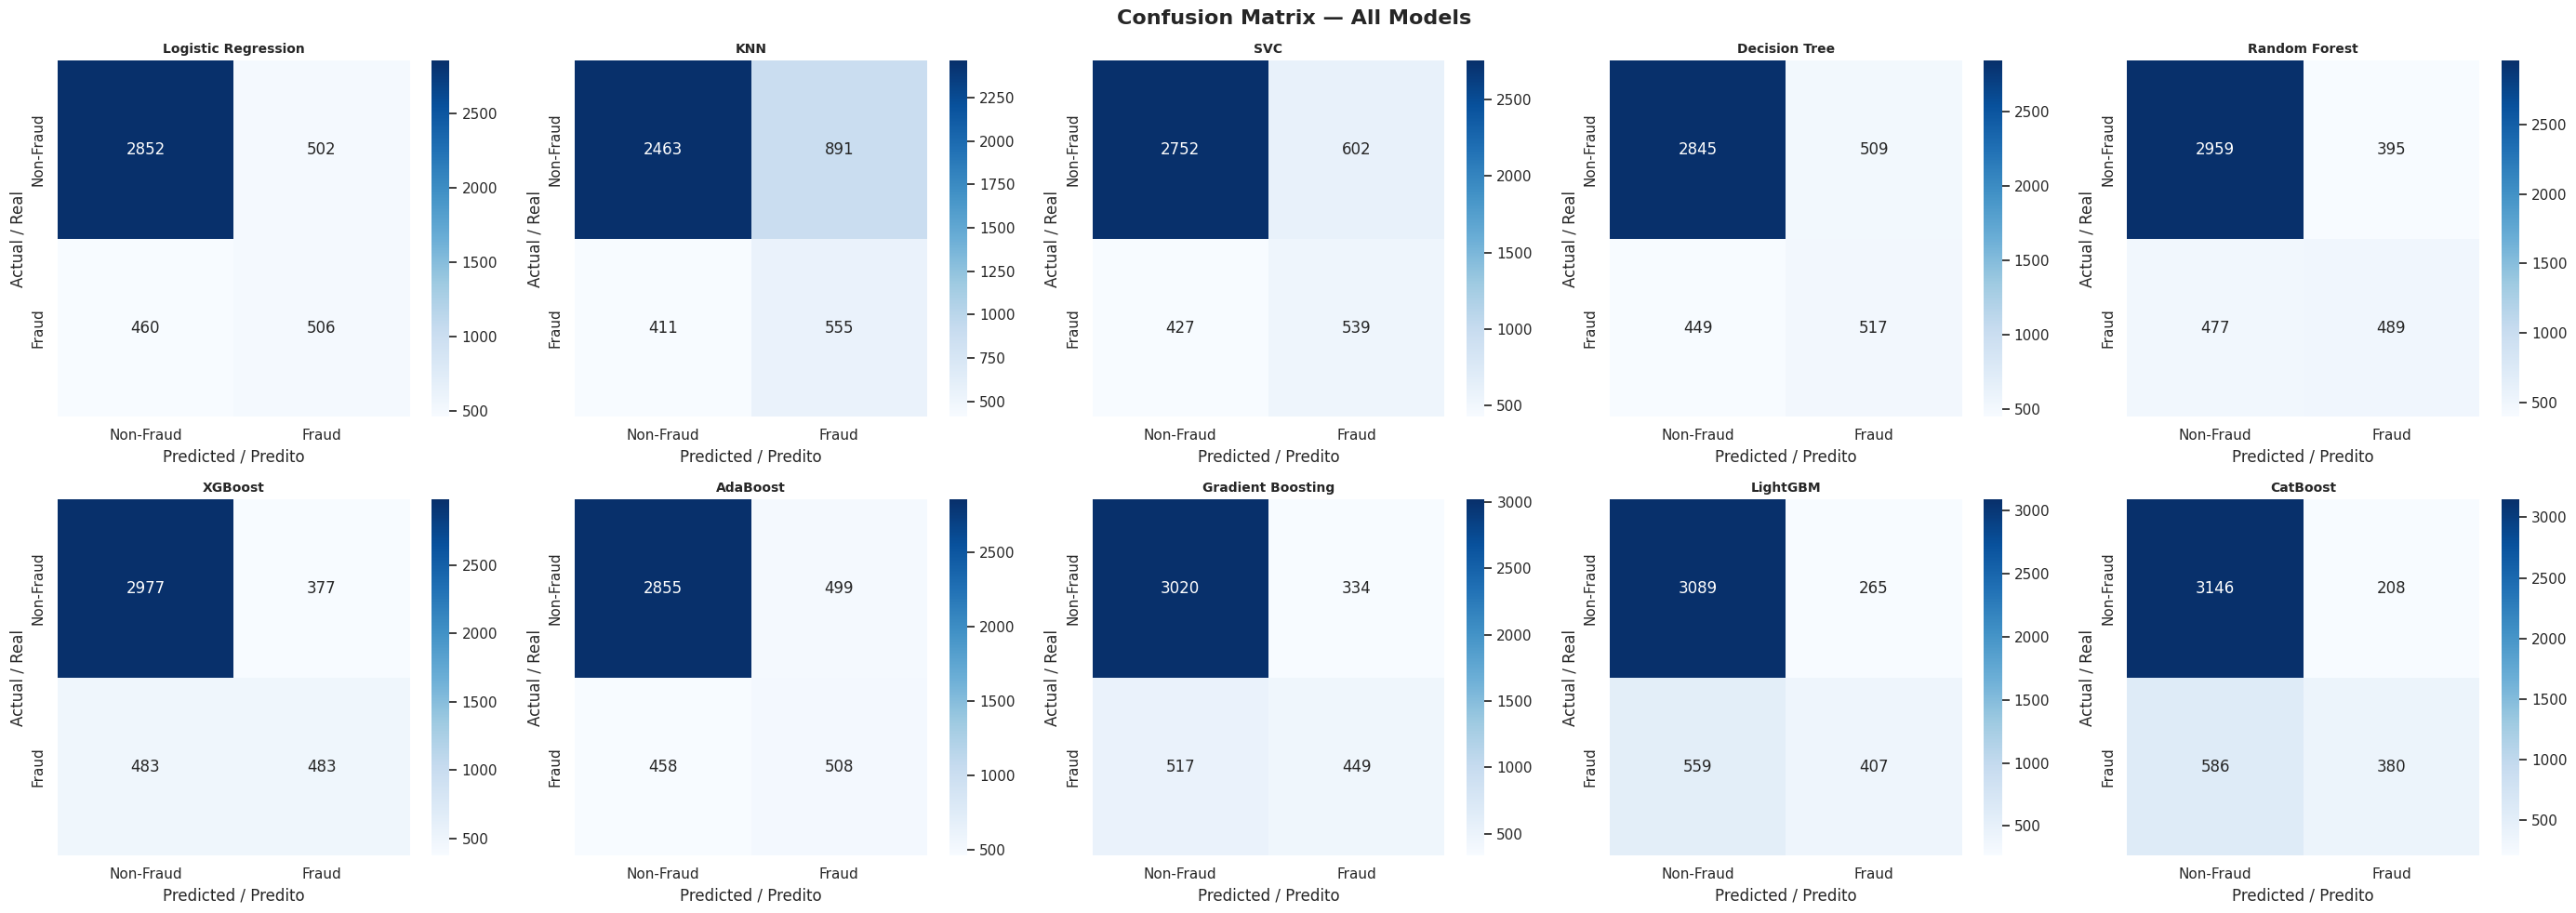

In [24]:
"""
Confusion matrix for all tuned models.
Matriz de confusão para todos os modelos otimizados.
"""

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 5, figsize=(28, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Fraud", "Fraud"],
        yticklabels=["Non-Fraud", "Fraud"],
        ax=axes[idx]
    )
    axes[idx].set_title(f"{name}", fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("Predicted / Predito")
    axes[idx].set_ylabel("Actual / Real")

plt.suptitle("Confusion Matrix — All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
#plt.savefig("img/09_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

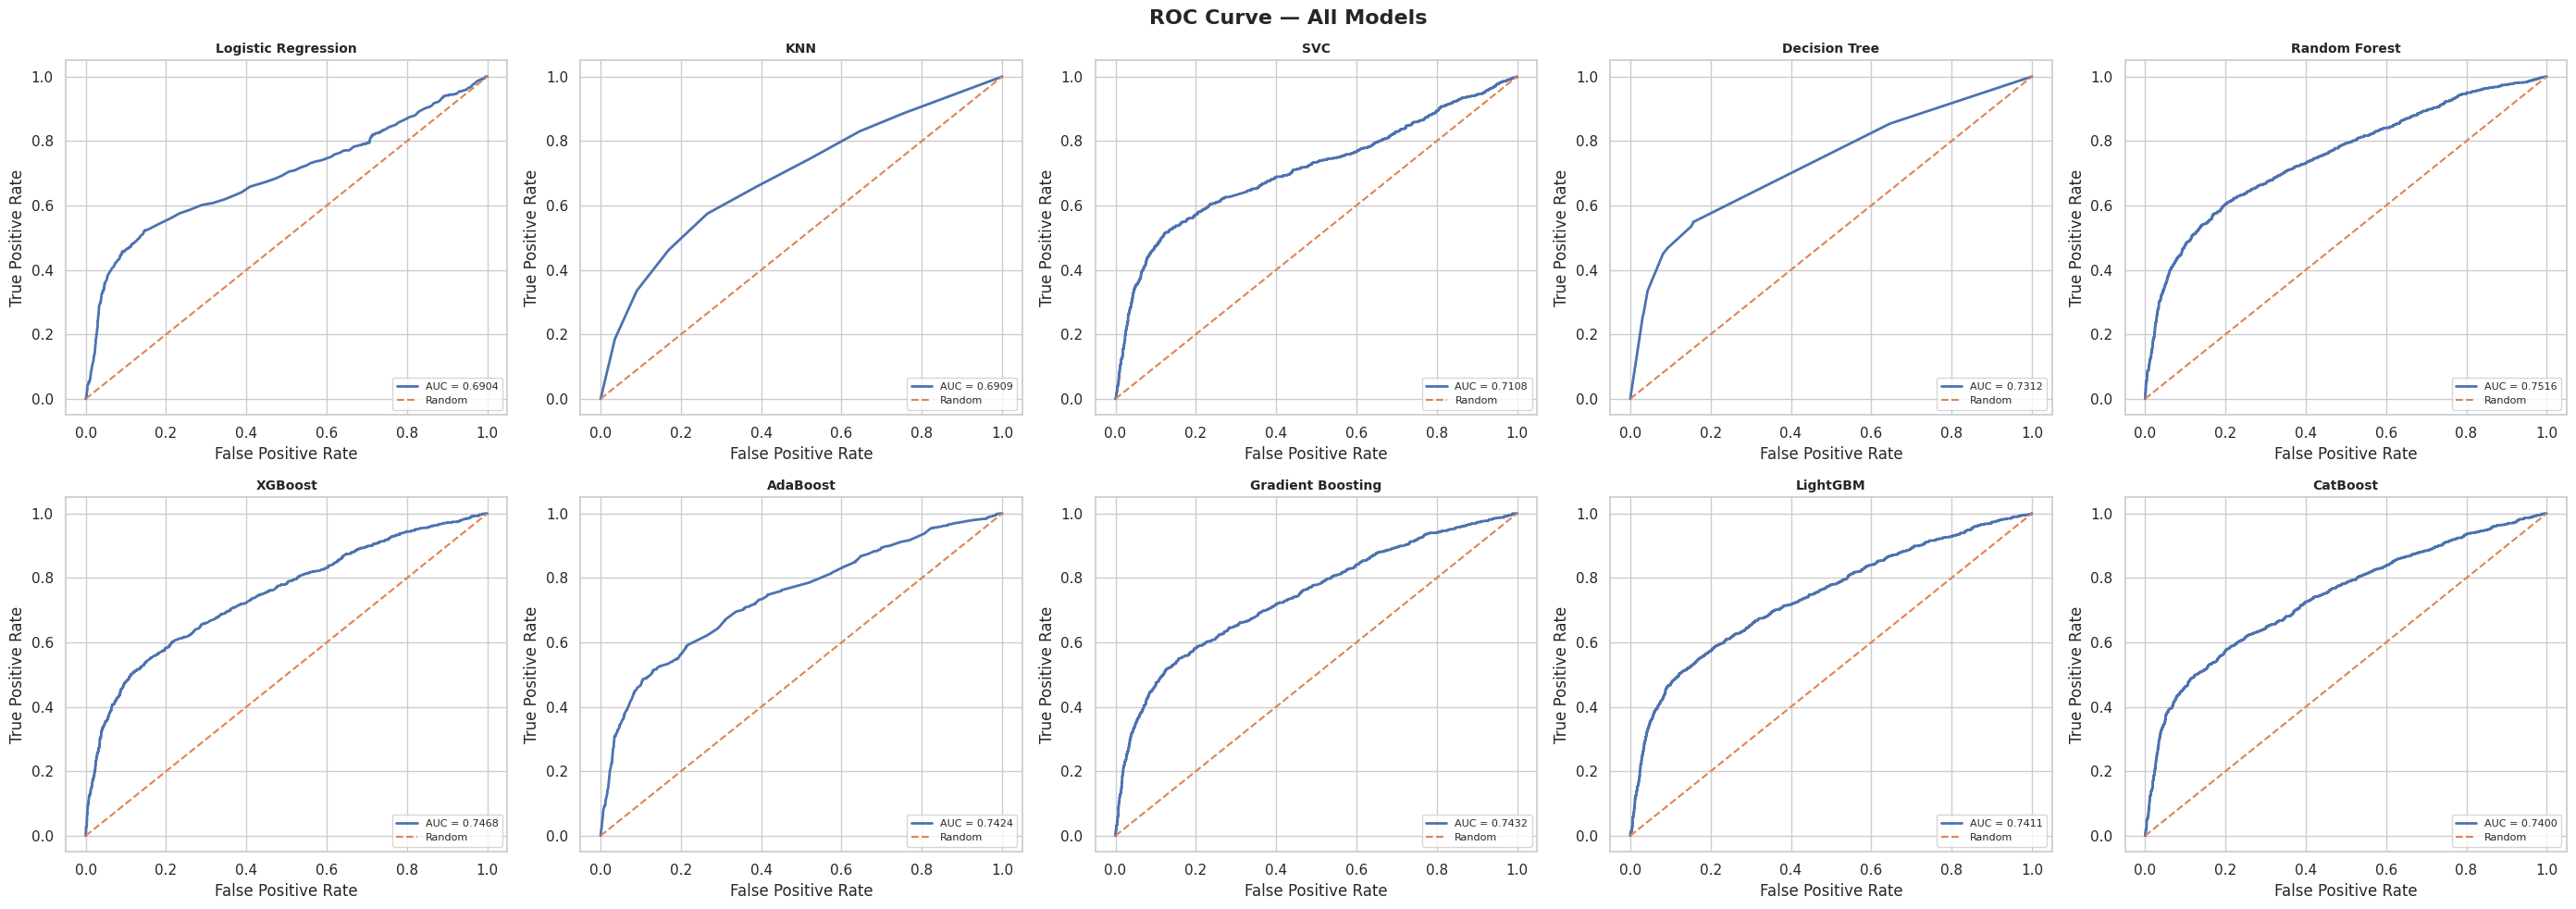

In [25]:
"""
ROC curve for all tuned models.
Curva ROC para todos os modelos otimizados.
"""

from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(2, 5, figsize=(28, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(tuned_models.items()):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)

    axes[idx].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {auc_score:.4f}")
    axes[idx].plot([0, 1], [0, 1], color="#DD8452", lw=1.5, linestyle="--", label="Random")
    axes[idx].set_title(f"{name}", fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].legend(loc="lower right", fontsize=8)

plt.suptitle("ROC Curve — All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
#plt.savefig("img/10_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
"""
Classification report for all tuned models.
Classification report para todos os modelos otimizados.
"""

from sklearn.metrics import classification_report

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'=' * 55}")
    print(f"Model: {name}")
    print(f"{'=' * 55}")
    print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))


Model: Logistic Regression
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.85      0.86      3354
       Fraud       0.50      0.52      0.51       966

    accuracy                           0.78      4320
   macro avg       0.68      0.69      0.68      4320
weighted avg       0.78      0.78      0.78      4320


Model: KNN
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.73      0.79      3354
       Fraud       0.38      0.57      0.46       966

    accuracy                           0.70      4320
   macro avg       0.62      0.65      0.63      4320
weighted avg       0.75      0.70      0.72      4320


Model: SVC
              precision    recall  f1-score   support

   Non-Fraud       0.87      0.82      0.84      3354
       Fraud       0.47      0.56      0.51       966

    accuracy                           0.76      4320
   macro avg       0.67      0.69      0.68      4320
weighted avg       0.7

In [27]:
"""
Save all trained models to disk.
Salva todos os modelos treinados em disco.
"""

import joblib
import os

os.makedirs("models", exist_ok=True)

for name, model in tuned_models.items():
    file_name = name.lower().replace(" ", "_")
    file_path = f"models/{file_name}.pkl"
    joblib.dump(model, file_path)
    size = os.path.getsize(file_path) / 1024
    print(f"Saved / Salvo: {file_path:<45} {size:.1f} KB")

print("\nAll models saved / Todos os modelos salvos!")

Saved / Salvo: models/logistic_regression.pkl                0.9 KB
Saved / Salvo: models/knn.pkl                                3933.4 KB
Saved / Salvo: models/svc.pkl                                1676.1 KB
Saved / Salvo: models/decision_tree.pkl                      3.2 KB
Saved / Salvo: models/random_forest.pkl                      2555.3 KB
Saved / Salvo: models/xgboost.pkl                            475.4 KB
Saved / Salvo: models/adaboost.pkl                           32.7 KB
Saved / Salvo: models/gradient_boosting.pkl                  139.9 KB
Saved / Salvo: models/lightgbm.pkl                           339.9 KB
Saved / Salvo: models/catboost.pkl                           1096.7 KB

All models saved / Todos os modelos salvos!


In [28]:
"""
Final model comparison dataframe with all metrics.
Dataframe final de comparação de modelos com todas as métricas.
"""

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

final_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    final_results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
        "AUC":       roc_auc_score(y_test, y_prob),
    })

final_df = (
    pd.DataFrame(final_results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

def highlight_best(row):
    """Highlight best model row in gold / Destaca linha do melhor modelo em dourado."""
    if row["Model"] == final_df.iloc[0]["Model"]:
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

display(
    final_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
        "AUC":       "{:.4f}",
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,CatBoost,0.8162,0.6463,0.3934,0.4891,0.7400
1,LightGBM,0.8093,0.6057,0.4213,0.4969,0.7411
2,Gradient Boosting,0.8030,0.5734,0.4648,0.5134,0.7432
3,XGBoost,0.8009,0.5616,0.5000,0.5290,0.7468
4,Random Forest,0.7981,0.5532,0.5062,0.5286,0.7516
5,AdaBoost,0.7785,0.5045,0.5259,0.5150,0.7424
6,Decision Tree,0.7782,0.5039,0.5352,0.5191,0.7312
7,Logistic Regression,0.7773,0.5020,0.5238,0.5127,0.6904
8,SVC,0.7618,0.4724,0.5580,0.5116,0.7108
9,KNN,0.6986,0.3838,0.5745,0.4602,0.6909


**Analysis / Análise — Model Comparison: Without vs With Hyperparameter Tuning**

**Results / Resultados**

**Without Hyperparameter Tuning / Sem Hiperparâmetro**

| # | Model | CV Mean | CV Std | Test Accuracy |
|---|---|---|---|---|
| 1 | **LightGBM** | **0.6845** | 0.0050 | **0.6879** |
| 2 | AdaBoost | 0.6918 | 0.0091 | 0.6873 |
| 3 | CatBoost | 0.6895 | 0.0051 | 0.6841 |
| 4 | Gradient Boosting | 0.6933 | 0.0077 | 0.6808 |
| 5 | SVC | 0.6777 | 0.0087 | 0.6775 |
| 6 | Random Forest | 0.6637 | 0.0075 | 0.6688 |
| 7 | XGBoost | 0.6686 | 0.0044 | 0.6634 |
| 8 | KNN | 0.6406 | 0.0072 | 0.6585 |
| 9 | Logistic Regression | 0.6622 | 0.0099 | 0.6574 |
| 10 | Decision Tree | 0.5955 | 0.0078 | 0.6107 |

**With Hyperparameter Tuning + SMOTE / Com Hiperparâmetro + SMOTE**

| # | Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| 1 | **CatBoost** | **0.8162** | **0.6463** | 0.3934 | 0.4891 |
| 2 | LightGBM | 0.8093 | 0.6057 | 0.4213 | 0.4969 |
| 3 | Gradient Boosting | 0.8030 | 0.5734 | 0.4648 | 0.5134 |
| 4 | XGBoost | 0.8009 | 0.5616 | 0.5000 | 0.5290 |
| 5 | Random Forest | 0.7981 | 0.5532 | 0.5062 | 0.5286 |
| 6 | AdaBoost | 0.7785 | 0.5045 | 0.5259 | 0.5150 |
| 7 | Decision Tree | 0.7782 | 0.5039 | 0.5352 | 0.5191 |
| 8 | Logistic Regression | 0.7773 | 0.5020 | 0.5238 | 0.5127 |
| 9 | SVC | 0.7618 | 0.4724 | 0.5580 | 0.5116 |
| 10 | KNN | 0.6986 | 0.3838 | 0.5745 | 0.4602 |

**Gain Analysis / Análise de Ganho**

| Model | Before / Antes | After / Depois | Gain / Ganho |
|---|---|---|---|
| **CatBoost** | 0.6841 | **0.8162** | **+13.21pp** |
| **LightGBM** | 0.6879 | 0.8093 | +12.14pp |
| **Gradient Boosting** | 0.6808 | 0.8030 | +12.22pp |
| **XGBoost** | 0.6634 | 0.8009 | +13.75pp |
| **Random Forest** | 0.6688 | 0.7981 | +12.93pp |
| **AdaBoost** | 0.6873 | 0.7785 | +9.12pp |
| **Decision Tree** | 0.6107 | 0.7782 | +16.75pp |
| **Logistic Regression** | 0.6574 | 0.7773 | +11.99pp |
| **SVC** | 0.6775 | 0.7618 | +8.43pp |
| **KNN** | 0.6585 | 0.6986 | +4.01pp |

**Detailed Analysis / Análise Detalhada**

**EN:**

The combination of **SMOTE + hyperparameter tuning** produced substantial accuracy gains across all models. The most dramatic improvement belongs to **Decision Tree (+16.75pp)**, which jumped from 0.6107 to 0.7782, reflecting how much this model benefits from controlled depth and leaf constraints via GridSearchCV. **XGBoost** showed the second largest absolute gain (+13.75pp), followed closely by **CatBoost (+13.21pp)** which became the new champion with **81.62% accuracy**.

The ranking shifted significantly after tuning. **LightGBM** led before tuning (0.6879) but dropped to second place after tuning (0.8093), overtaken by **CatBoost (0.8162)**. **AdaBoost** showed the smallest relative gain among boosting models (+9.12pp), suggesting it was already closer to its performance ceiling without tuning. **KNN** showed the weakest improvement overall (+4.01pp, from 0.6585 to 0.6986), confirming that distance-based models benefit less from SMOTE oversampling compared to tree-based ensembles.

The **Precision-Recall tradeoff** is clearly visible in the tuned results: CatBoost leads in Precision (0.6463) but has the lowest Recall (0.3934) among the top models, while **XGBoost** offers the best Precision-Recall balance with Precision=0.5616 and Recall=0.5000, producing the highest F1-Score among the top 4 models (0.5290). For fraud detection specifically, where catching actual fraudsters (Recall) is critical, **Gradient Boosting** and **XGBoost** offer a more practical balance than CatBoost.

**PT:**

A combinação de **SMOTE + tuning de hiperparâmetros** produziu ganhos substanciais de acurácia em todos os modelos. A melhoria mais dramática pertence à **Decision Tree (+16,75pp)**, que saltou de 0,6107 para 0,7782, refletindo o quanto esse modelo se beneficia de restrições controladas de profundidade e folha via GridSearchCV. **XGBoost** mostrou o segundo maior ganho absoluto (+13,75pp), seguido de perto por **CatBoost (+13,21pp)** que se tornou o novo campeão com **81,62% de acurácia**.

O ranking mudou significativamente após o tuning. **LightGBM** liderou antes do tuning (0,6879) mas caiu para o segundo lugar após (0,8093), superado pelo **CatBoost (0,8162)**. **AdaBoost** mostrou o menor ganho relativo entre os modelos de boosting (+9,12pp), sugerindo que já estava mais próximo de seu teto de desempenho sem tuning. **KNN** mostrou a menor melhoria geral (+4,01pp), confirmando que modelos baseados em distância se beneficiam menos do SMOTE comparado a ensembles de árvore.

O **tradeoff Precision-Recall** é claramente visível nos resultados tunados: CatBoost lidera em Precision (0,6463) mas tem o menor Recall (0,3934) entre os melhores modelos, enquanto **XGBoost** oferece o melhor equilíbrio Precision-Recall com Precision=0,5616 e Recall=0,5000, produzindo o maior F1-Score entre os 4 primeiros (0,5290). Para detecção de fraude especificamente, onde capturar fraudadores reais (Recall) é crítico, **Gradient Boosting** e **XGBoost** oferecem um equilíbrio mais prático que CatBoost.

**Key Takeaways / Principais Conclusões**

| Insight | EN | PT |
|---|---|---|
| **Champion after tuning** | CatBoost (81.62%) | CatBoost (81,62%) |
| **Biggest accuracy gain** | Decision Tree (+16.75pp) | Decision Tree (+16,75pp) |
| **Smallest gain** | KNN (+4.01pp) | KNN (+4,01pp) |
| **Best F1-Score** | XGBoost (0.5290) | XGBoost (0,5290) |
| **Best for fraud recall** | KNN (0.5745) | KNN (0,5745) |
| **Best precision** | CatBoost (0.6463) | CatBoost (0,6463) |
| **SMOTE impact** | +10.5pp average across all models | +10,5pp média em todos os modelos |

# **Section B) Machine Learning Model 2 - Improved Hyperparameters**

In [29]:
"""
CatBoost champion model optimization — threshold tuning, calibration and KFold.
Otimização do modelo campeão CatBoost — ajuste de limiar, calibração e KFold.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [30]:
"""
Step 1 — Hyperparameter optimization with RandomizedSearchCV and StratifiedKFold.
Passo 1 — Otimização de hiperparâmetros com RandomizedSearchCV e StratifiedKFold.
"""

# HYPERPARAMETER GRID / GRADE DE HIPERPARÂMETROS
param_grid = {
    "classifier__iterations":        [300, 500, 700, 1000],
    "classifier__learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "classifier__depth":             [4, 6, 8, 10],
    "classifier__l2_leaf_reg":       [1, 3, 5, 7, 9],
    "classifier__border_count":      [32, 64, 128],
    "classifier__bagging_temperature":[0, 0.5, 1.0],
    "classifier__random_strength":   [1, 2, 5],
}

# PIPELINE WITH SMOTE AND CATBOOST / PIPELINE COM SMOTE E CATBOOST
pipeline = ImbPipeline([
    ("smote",      SMOTE(random_state=42)),
    ("classifier", CatBoostClassifier(random_state=42, verbose=0)),
])

# STRATIFIED KFOLD / KFOLD ESTRATIFICADO
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RANDOMIZED SEARCH / BUSCA ALEATÓRIA
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring="recall",
    cv=kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter search / Iniciando busca de hiperparâmetros...")
search.fit(X_train, y_train)

Starting hyperparameter search / Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              CatBoostClassifier(random_state=42, verbose=0))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'classifier__bagging_temperature': [0,
                                                                            0.5,
                                                                            1.0],
                                        'classifier__border_count': [32, 64,
                                                                     128],
                                        'classifier__depth': [4, 6, 8, 10],
                                        'classifier__iterations': [300, 500,
                                                                   700, 1000],
                                        'classifier__l2_leaf_reg': [1, 3, 5, 7,
                                                                    9],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__random_strength': [1, 2,
                                                                        5]},
                   random_state=42, scoring='recall', verbose=1)

In [31]:
print(f"\nBest parameters / Melhores parâmetros:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV Recall: {search.best_score_:.4f}")


Best parameters / Melhores parâmetros:
  classifier__random_strength: 5
  classifier__learning_rate: 0.01
  classifier__l2_leaf_reg: 9
  classifier__iterations: 300
  classifier__depth: 4
  classifier__border_count: 64
  classifier__bagging_temperature: 0.5

Best CV Recall: 0.4700


In [32]:
best_model = search.best_estimator_

In [33]:
"""
Step 2 — Probability calibration using isotonic regression.
Passo 2 — Calibração de probabilidade usando regressão isotônica.
"""

# CALIBRATE MODEL / CALIBRA MODELO
print("Calibrating model / Calibrando modelo...")
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="isotonic",
    cv=kfold
)
calibrated_model.fit(X_train, y_train)
print("Calibration complete / Calibração concluída.")

Calibrating model / Calibrando modelo...
Calibration complete / Calibração concluída.


In [46]:
%%time

"""
Learning curve analysis for all tuned models.
Análise de curva de aprendizado para todos os modelos otimizados.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, ShuffleSplit
from tqdm import tqdm

# MODELS FOR LEARNING CURVE / MODELOS PARA CURVA DE APRENDIZADO
learning_curve_models = {
    "Logistic Regression": best_estimators["Logistic Regression"],
    "KNN":                 best_estimators["KNN"],
    "Decision Tree":       best_estimators["Decision Tree"],
    "Random Forest":       best_estimators["Random Forest"],
    "XGBoost":             best_estimators["XGBoost"],
    "Gradient Boosting":   tuned_models["Gradient Boosting"],
    "LightGBM":            tuned_models["LightGBM"],
    "CatBoost":            tuned_models["CatBoost"],
}

# CROSS VALIDATION SETUP / CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
cv           = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
train_sizes  = np.linspace(0.1, 1.0, 5)

# COMPUTE LEARNING CURVES / CALCULA CURVAS DE APRENDIZADO
lc_results = {}

pbar = tqdm(learning_curve_models.items(), total=len(learning_curve_models), desc="Computing learning curves / Calculando curvas", unit="model")

for name, model in pbar:
    pbar.set_description(f"Learning curve / Curva: {name:<25}")
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model,
        X_train, y_train,
        cv=cv,
        train_sizes=train_sizes,
        scoring="accuracy",
        n_jobs=-1
    )
    lc_results[name] = {
        "train_sizes": train_sizes_abs,
        "train_mean":  np.mean(train_scores, axis=1),
        "train_std":   np.std(train_scores, axis=1),
        "val_mean":    np.mean(val_scores, axis=1),
        "val_std":     np.std(val_scores, axis=1),
    }
    pbar.set_postfix({
        "Final Train": f"{np.mean(train_scores, axis=1)[-1]:.4f}",
        "Final Val":   f"{np.mean(val_scores, axis=1)[-1]:.4f}",
    })

print("Learning curves computed / Curvas de aprendizado calculadas!")

Learning curve / Curva: CatBoost                 : 100%|██████████| 8/8 [05:45<00:00, 43.23s/model, Final Train=0.8449, Final Val=0.8141]

Learning curves computed / Curvas de aprendizado calculadas!
CPU times: user 1.61 s, sys: 293 ms, total: 1.9 s
Wall time: 5min 45s


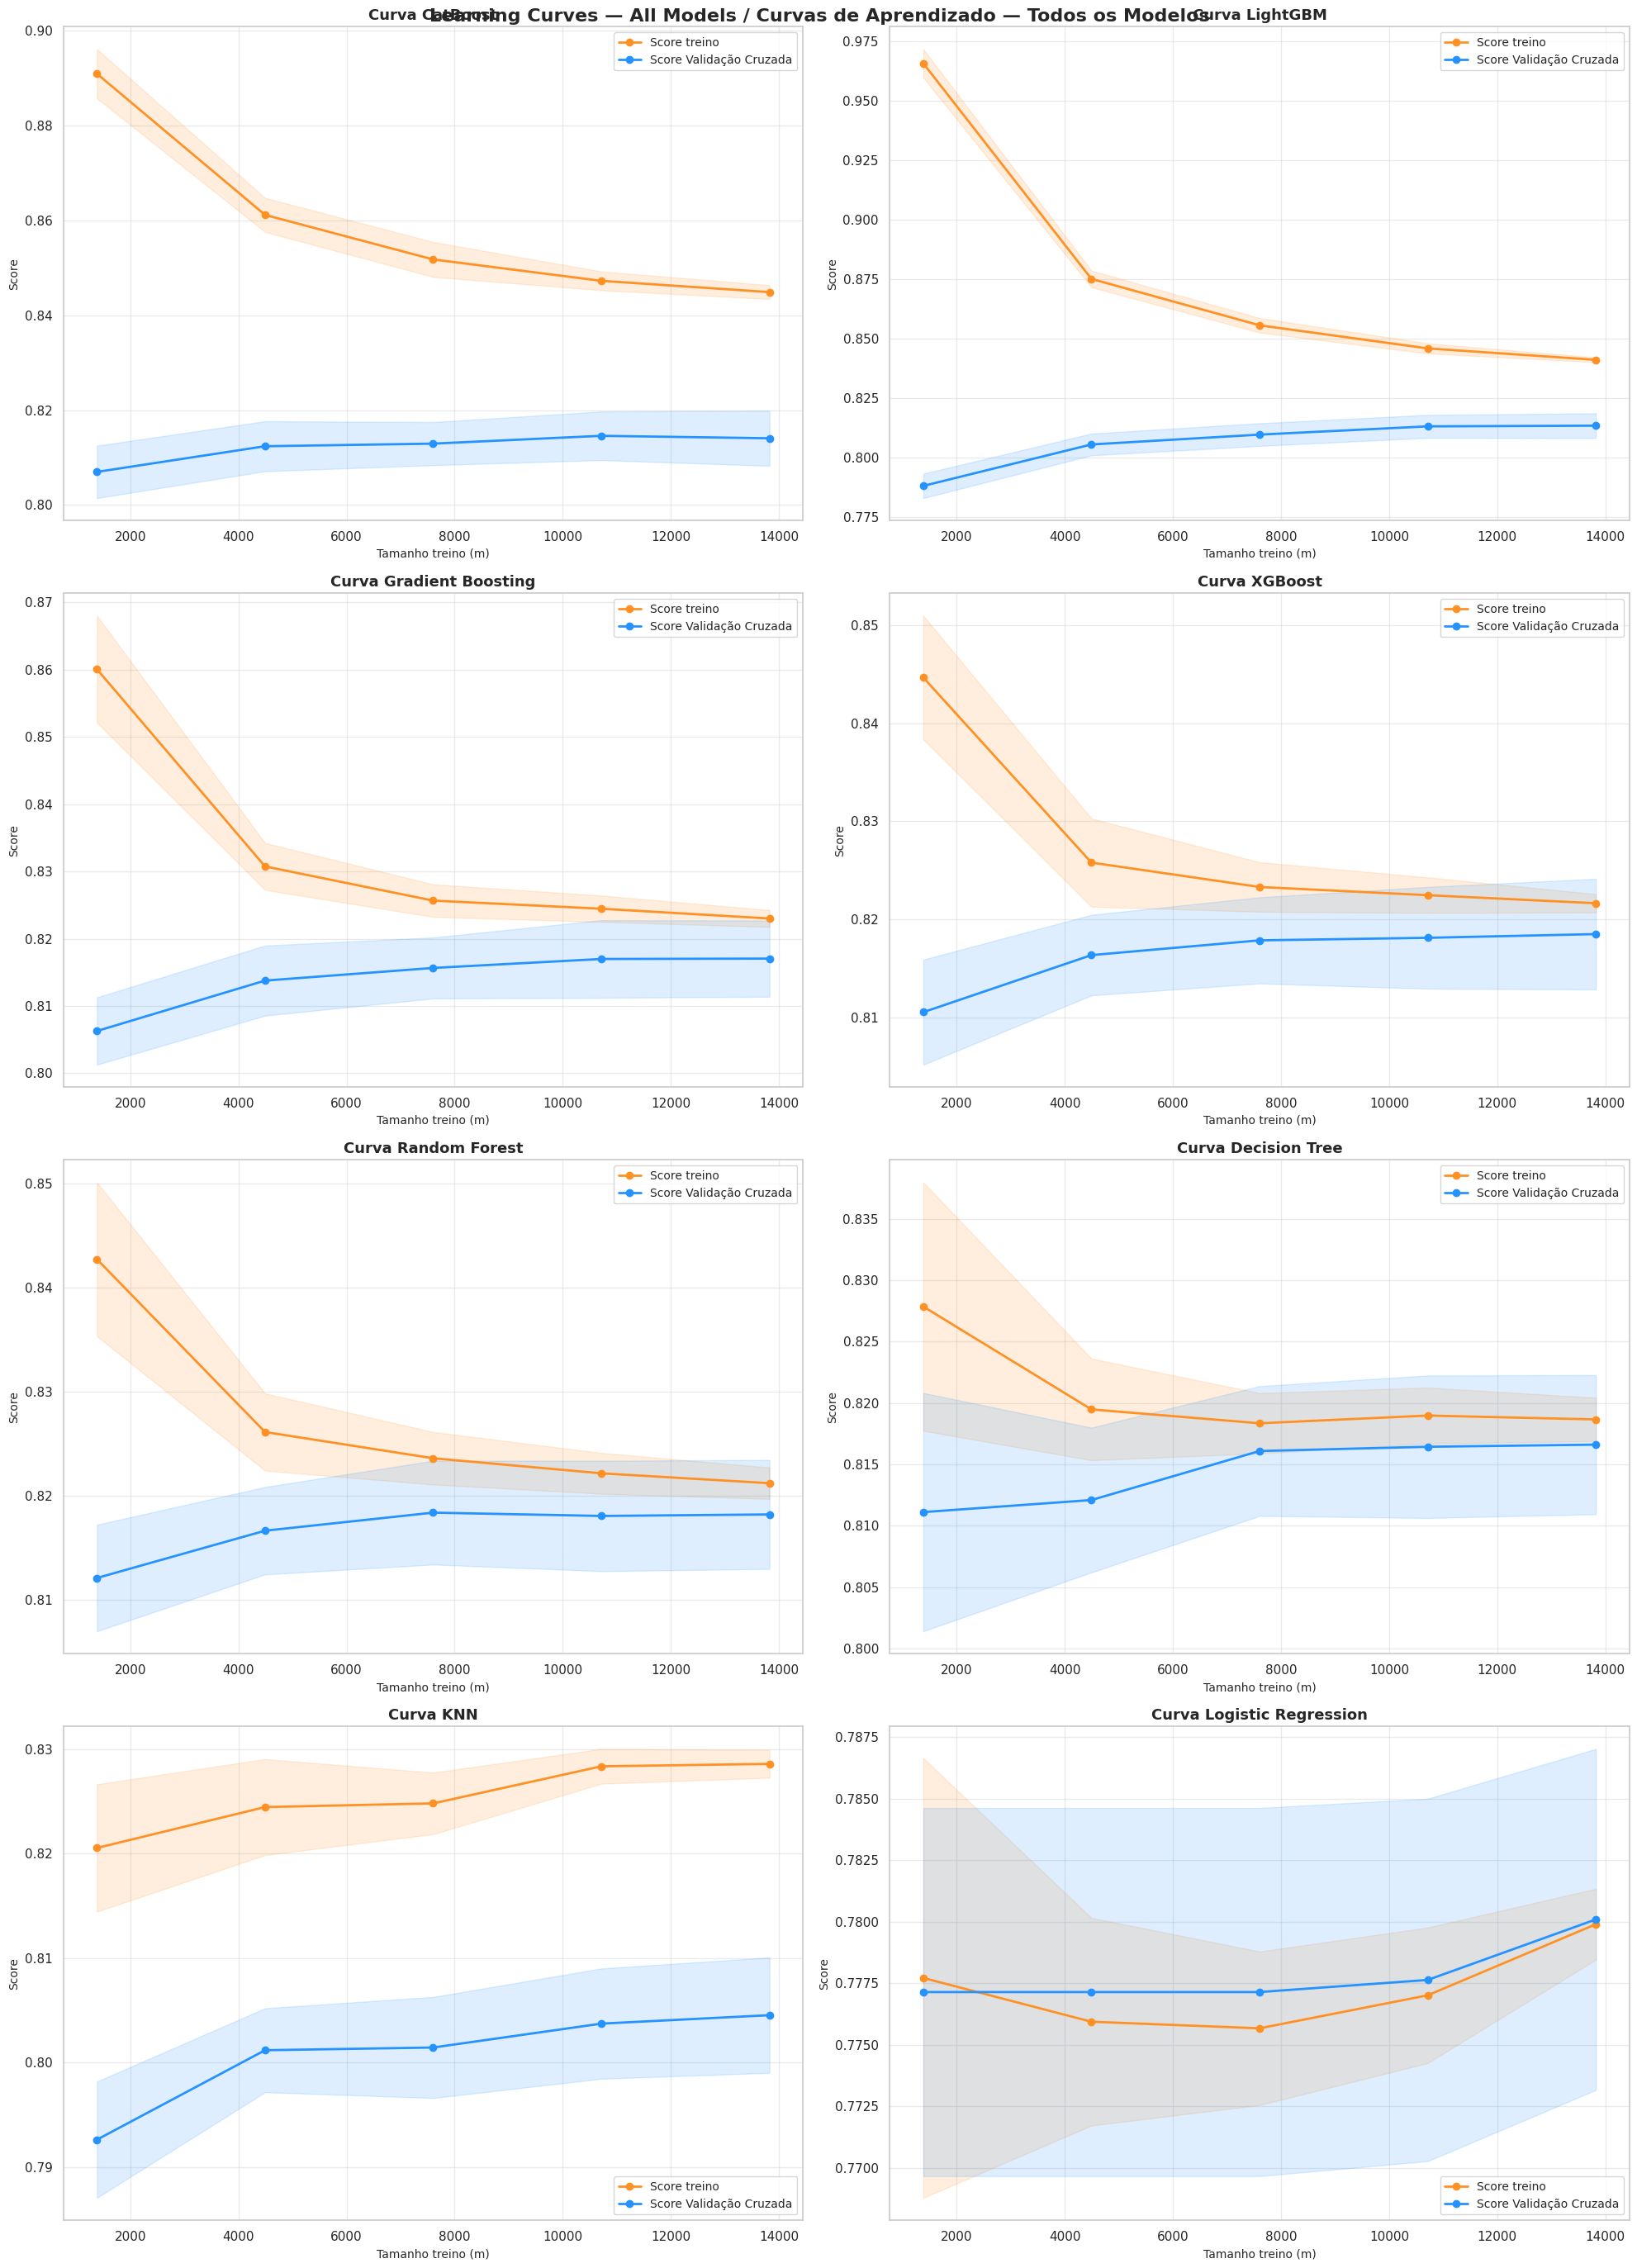

In [49]:
"""
Plot learning curves for all 8 models — detailed view.
Plota curvas de aprendizado para todos os 8 modelos — visão detalhada.
"""

all_models = ["CatBoost", "LightGBM", "Gradient Boosting", "XGBoost", "Random Forest", "Decision Tree", "KNN", "Logistic Regression"]

# 4 ROWS x 2 COLUMNS FOR 8 MODELS / 4 LINHAS x 2 COLUNAS PARA 8 MODELOS
fig, axes = plt.subplots(4, 2, figsize=(20, 28))
axes      = axes.flatten()

for idx, name in enumerate(all_models):

    results     = lc_results[name]
    train_sizes = results["train_sizes"]
    train_mean  = results["train_mean"]
    train_std   = results["train_std"]
    val_mean    = results["val_mean"]
    val_std     = results["val_std"]

    ax = axes[idx]

    # TRAIN SCORE BAND / BANDA DO SCORE DE TREINO
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#FF9124"
    )

    # VALIDATION SCORE BAND / BANDA DO SCORE DE VALIDAÇÃO
    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="#2492FF"
    )

    # TRAIN SCORE LINE / LINHA DO SCORE DE TREINO
    ax.plot(
        train_sizes, train_mean,
        "o-",
        color="#FF9124",
        lw=2,
        label="Score treino"
    )

    # VALIDATION SCORE LINE / LINHA DO SCORE DE VALIDAÇÃO
    ax.plot(
        train_sizes, val_mean,
        "o-",
        color="#2492FF",
        lw=2,
        label="Score Validação Cruzada"
    )

    ax.set_title(f"Curva {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tamanho treino (m)", fontsize=10)
    ax.set_ylabel("Score", fontsize=10)
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.4)

plt.suptitle("Learning Curves — All Models / Curvas de Aprendizado — Todos os Modelos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Best threshold / Melhor limiar: 0.29
At threshold — Accuracy: 0.7947 | Precision: 0.5425 | Recall: 0.5217 | F1: 0.5319


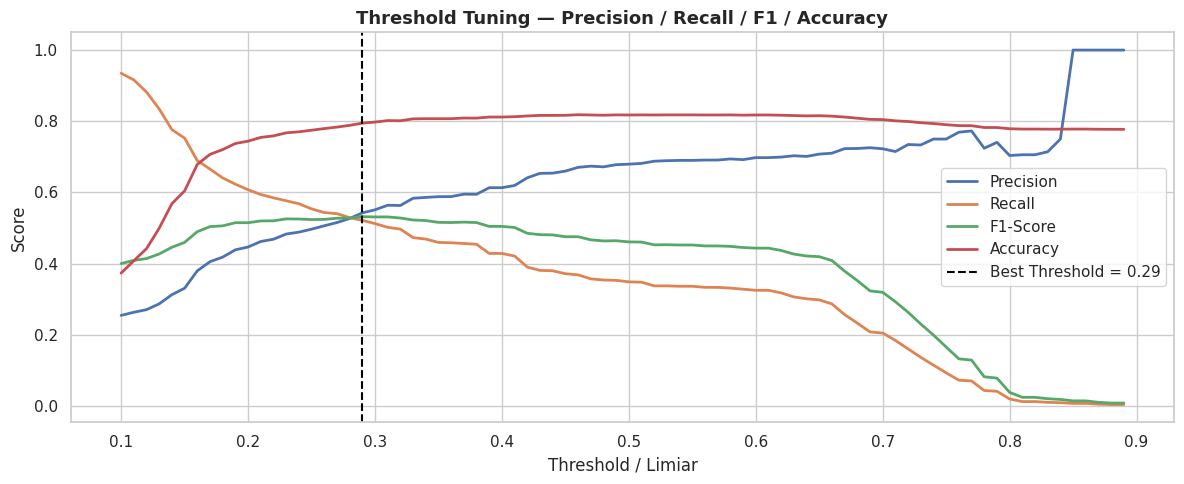

In [38]:
"""
Step 3 — Threshold tuning to maximize recall for fraud detection.
Passo 3 — Ajuste do limiar para maximizar recall na detecção de fraude.
"""

# PREDICT PROBABILITIES / PREDIZ PROBABILIDADES
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

# TEST MULTIPLE THRESHOLDS / TESTA MÚLTIPLOS LIMIARES
thresholds  = np.arange(0.1, 0.9, 0.01)
thresh_results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    thresh_results.append({
        "Threshold": threshold,
        "Accuracy":  accuracy_score(y_test, y_pred_thresh),
        "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_thresh, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred_thresh, zero_division=0),
    })

thresh_df = pd.DataFrame(thresh_results)

# FIND BEST THRESHOLD BY F1 / ENCONTRA MELHOR LIMIAR PELO F1
best_thresh_row = thresh_df.loc[thresh_df["F1-Score"].idxmax()]
best_threshold  = best_thresh_row["Threshold"]
print(f"Best threshold / Melhor limiar: {best_threshold:.2f}")
print(f"At threshold — Accuracy: {best_thresh_row['Accuracy']:.4f} | Precision: {best_thresh_row['Precision']:.4f} | Recall: {best_thresh_row['Recall']:.4f} | F1: {best_thresh_row['F1-Score']:.4f}")

# PLOT THRESHOLD CURVES / PLOTA CURVAS DE LIMIAR
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresh_df["Threshold"], thresh_df["Precision"], label="Precision", color="#4C72B0", lw=2)
ax.plot(thresh_df["Threshold"], thresh_df["Recall"],    label="Recall",    color="#DD8452", lw=2)
ax.plot(thresh_df["Threshold"], thresh_df["F1-Score"],  label="F1-Score",  color="#55A868", lw=2)
ax.plot(thresh_df["Threshold"], thresh_df["Accuracy"],  label="Accuracy",  color="#C44E52", lw=2)
ax.axvline(x=best_threshold, color="black", linestyle="--", lw=1.5, label=f"Best Threshold = {best_threshold:.2f}")
ax.set_title("Threshold Tuning — Precision / Recall / F1 / Accuracy", fontsize=13, fontweight="bold")
ax.set_xlabel("Threshold / Limiar")
ax.set_ylabel("Score")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

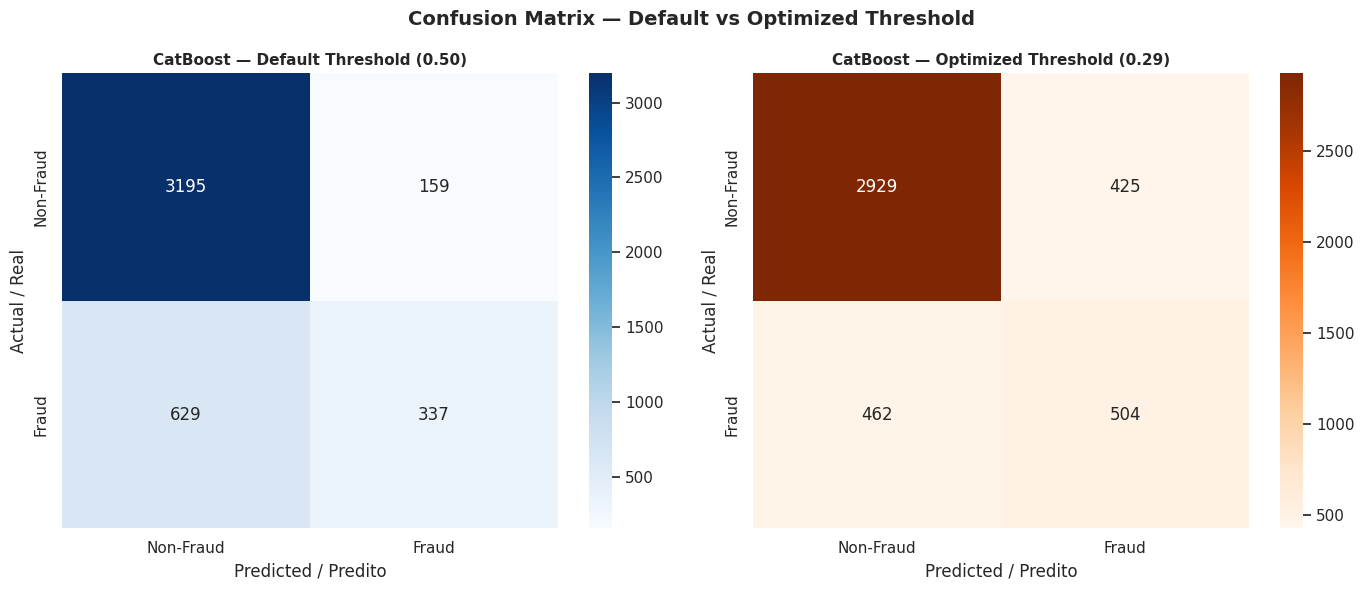

In [39]:
"""
Step 4 — Final predictions with optimal threshold and full evaluation.
Passo 4 — Predições finais com limiar ótimo e avaliação completa.
"""

# APPLY BEST THRESHOLD / APLICA MELHOR LIMIAR
y_pred_optimized = (y_prob >= best_threshold).astype(int)
y_pred_default   = calibrated_model.predict(X_test)

# CONFUSION MATRIX COMPARISON / COMPARAÇÃO DE MATRIZES DE CONFUSÃO
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_default, y_pred_optimized],
    ["CatBoost — Default Threshold (0.50)", f"CatBoost — Optimized Threshold ({best_threshold:.2f})"],
    [plt.cm.Blues, plt.cm.Oranges]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["Non-Fraud", "Fraud"],
        yticklabels=["Non-Fraud", "Fraud"],
        ax=ax
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted / Predito")
    ax.set_ylabel("Actual / Real")

plt.suptitle("Confusion Matrix — Default vs Optimized Threshold", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

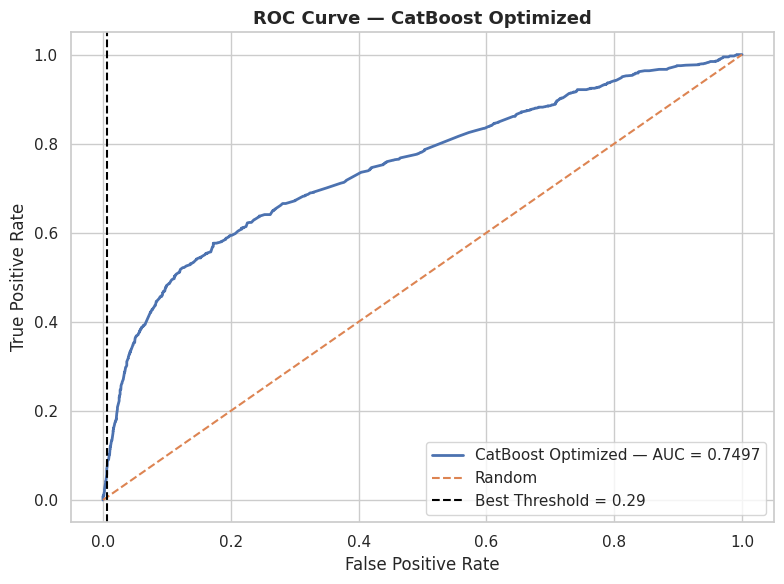

In [40]:
"""
Step 5 — ROC curve for optimized CatBoost model.
Passo 5 — Curva ROC para o modelo CatBoost otimizado.
"""

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"CatBoost Optimized — AUC = {auc_score:.4f}")
ax.plot([0, 1], [0, 1], color="#DD8452", lw=1.5, linestyle="--", label="Random")
ax.axvline(x=fpr[np.argmin(np.abs(thresholds - best_threshold))],
           color="black", linestyle="--", lw=1.5, label=f"Best Threshold = {best_threshold:.2f}")
ax.set_title("ROC Curve — CatBoost Optimized", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()
plt.show()

In [50]:
"""
Step 6 — Final comparison dataframe — default vs optimized threshold.
Passo 6 — Dataframe de comparação final — limiar padrão vs otimizado.
"""

comparison_df = pd.DataFrame([
    {
        "Model":     f"CatBoost — Default Threshold (0.50)",
        "Accuracy":  accuracy_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_default, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred_default, zero_division=0),
        "AUC":       roc_auc_score(y_test, y_prob),
    },
    {
        "Model":     f"CatBoost — Optimized Threshold ({best_threshold:.2f})",
        "Accuracy":  accuracy_score(y_test, y_pred_optimized),
        "Precision": precision_score(y_test, y_pred_optimized, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_optimized, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred_optimized, zero_division=0),
        "AUC":       roc_auc_score(y_test, y_prob),
    },
])

def highlight_best(row):
    """Highlight best model row in gold / Destaca linha do melhor modelo em dourado."""
    if row["Recall"] == comparison_df["Recall"].max():
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

print("Final Comparison / Comparação Final:\n")
display(
    comparison_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
        "AUC":       "{:.4f}",
    })
)

# CLASSIFICATION REPORT / RELATÓRIO DE CLASSIFICAÇÃO
print("\nClassification Report — Optimized Threshold / Limiar Otimizado:")

Final Comparison / Comparação Final:



,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,CatBoost — Default Threshold (0.50),0.8176,0.6794,0.3489,0.4610,0.7497
1,CatBoost — Optimized Threshold (0.29),0.7947,0.5425,0.5217,0.5319,0.7497



Classification Report — Optimized Threshold / Limiar Otimizado:


In [51]:
print(classification_report(y_test, y_pred_optimized, target_names=["Non-Fraud", "Fraud"]))

              precision    recall  f1-score   support

   Non-Fraud       0.86      0.87      0.87      3354
       Fraud       0.54      0.52      0.53       966

    accuracy                           0.79      4320
   macro avg       0.70      0.70      0.70      4320
weighted avg       0.79      0.79      0.79      4320



In [42]:
"""
Save optimized CatBoost model to disk.
Salva modelo CatBoost otimizado em disco.
"""

import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(calibrated_model, "models/catboost_optimized_calibrated.pkl")
joblib.dump(best_threshold,   "models/catboost_best_threshold.pkl")

print("Models saved / Modelos salvos:")
print("  models/catboost_optimized_calibrated.pkl")
print("  models/catboost_best_threshold.pkl")

Models saved / Modelos salvos:
  models/catboost_optimized_calibrated.pkl
  models/catboost_best_threshold.pkl


# **Secção C) Deep learning**

In [20]:
"""
Neural network models for credit card fraud detection using Keras/TensorFlow.
Modelos de rede neural para detecção de fraude em cartão de crédito usando Keras/TensorFlow.
"""

import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [21]:
"""
Neural network model 1 — Random undersampling dataset.
Modelo de rede neural 1 — Dataset com subamostragem aleatória.
"""

# INPUT SIZE / TAMANHO DA ENTRADA
n_inputs = X_train.shape[1]

# BUILD MODEL / CONSTRÓI MODELO
model_undersample = Sequential([
    Dense(n_inputs,      input_shape=(n_inputs,), activation="relu"),
    Dense(60,            activation="relu"),
    Dropout(0.2),
    Dense(60,            activation="relu"),
    Dense(30,            activation="relu"),
    Dense(2,             activation="softmax"),
])

# COMPILE MODEL / COMPILA MODELO
model_undersample.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

"""
Callbacks for training — early stopping and learning rate reduction.
Callbacks para treinamento — parada antecipada e redução da taxa de aprendizado.
"""

# EARLY STOPPING / PARADA ANTECIPADA
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# REDUCE LR ON PLATEAU / REDUZ LR AO PLATÔ
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_undersample.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            62 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,164 (24.08 KB)

 Trainable params: 6,164 (24.08 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
"""
Train neural network model 1 — undersampling dataset.
Treina modelo de rede neural 1 — dataset com subamostragem.
"""

# TRAIN MODEL / TREINA MODELO
history_undersample = model_undersample.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=25,
    epochs=150,
    shuffle=True,
    verbose=1)

# EVALUATE ON TRAIN / AVALIA NO TREINO
train_loss, train_acc = model_undersample.evaluate(X_train, y_train, verbose=0)
print(f"\nTrain Loss / Perda treino:      {train_loss:.4f}")
print(f"Train Accuracy / Acurácia treino: {train_acc:.4f}")

Epoch 1/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7685 - loss: 0.5881 - val_accuracy: 0.8076 - val_loss: 0.4880
Epoch 2/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8018 - loss: 0.4832 - val_accuracy: 0.8084 - val_loss: 0.4674
Epoch 3/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8074 - loss: 0.4721 - val_accuracy: 0.8116 - val_loss: 0.4645
Epoch 4/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8096 - loss: 0.4663 - val_accuracy: 0.8111 - val_loss: 0.4628
Epoch 5/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8118 - loss: 0.4648 - val_accuracy: 0.8151 - val_loss: 0.4605
Epoch 6/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8117 - loss: 0.4641 - val_accuracy: 0.8128 - val_loss: 0.4604
Epoch 7/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8115 - loss: 0.4620 - val_accuracy: 0.8119 - val_loss: 0.4591
Epoch 8/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8121 - loss: 0.4612 - val_accu

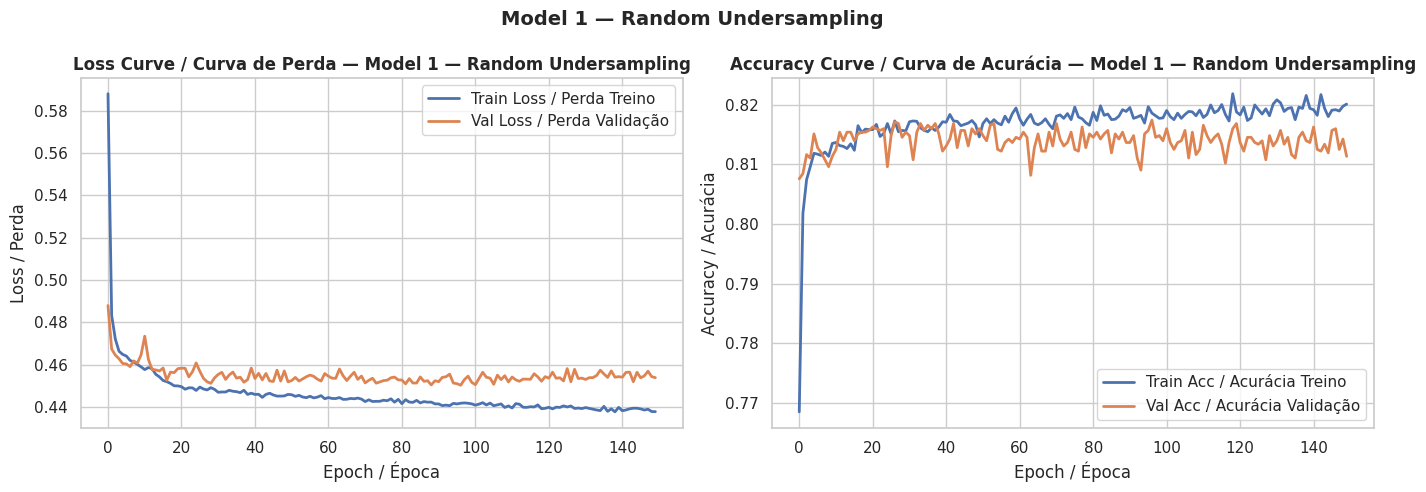

In [23]:
"""
Plot training history — loss and accuracy curves.
Plota histórico de treinamento — curvas de perda e acurácia.
"""

def plot_training_history(history, title):
    """Plot loss and accuracy curves / Plota curvas de perda e acurácia."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # LOSS CURVE / CURVA DE PERDA
    axes[0].plot(history.history["loss"],     label="Train Loss / Perda Treino",     color="#4C72B0", lw=2)
    axes[0].plot(history.history["val_loss"], label="Val Loss / Perda Validação",    color="#DD8452", lw=2)
    axes[0].set_title(f"Loss Curve / Curva de Perda — {title}", fontweight="bold")
    axes[0].set_xlabel("Epoch / Época")
    axes[0].set_ylabel("Loss / Perda")
    axes[0].legend()
    axes[0].grid(True)

    # ACCURACY CURVE / CURVA DE ACURÁCIA
    axes[1].plot(history.history["accuracy"],     label="Train Acc / Acurácia Treino",    color="#4C72B0", lw=2)
    axes[1].plot(history.history["val_accuracy"], label="Val Acc / Acurácia Validação",   color="#DD8452", lw=2)
    axes[1].set_title(f"Accuracy Curve / Curva de Acurácia — {title}", fontweight="bold")
    axes[1].set_xlabel("Epoch / Época")
    axes[1].set_ylabel("Accuracy / Acurácia")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_training_history(history_undersample, "Model 1 — Random Undersampling")

In [24]:
"""
Confusion matrix plot function.
Função de plot da matriz de confusão.
"""

def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion Matrix", cmap=plt.cm.Blues):
    """
    Plot confusion matrix with normalization option.
    Plota matriz de confusão com opção de normalização.
    """
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix / Matriz de confusão normalizada")
    else:
        print("Confusion matrix / Matriz de confusão")

    print(cm)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax)

    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, rotation=45)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes)

    fmt    = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j, i,
            format(cm[i, j], fmt),
            ha="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12,
            fontweight="bold"
        )

    ax.set_ylabel("True Class / Classe Verdadeira")
    ax.set_xlabel("Predicted Class / Classe Prevista")
    plt.tight_layout()
    plt.show()

Confusion matrix / Matriz de confusão
[[3216  138]
 [ 669  297]]


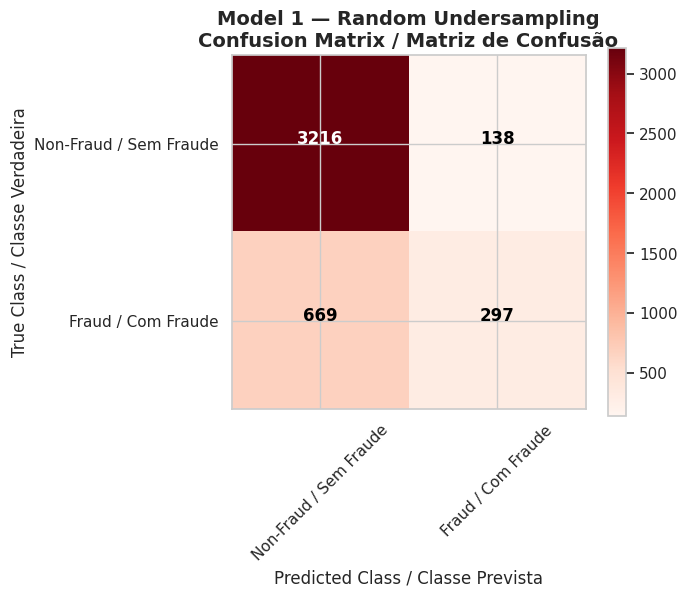

In [26]:
"""
Evaluate model 1 — predictions and confusion matrix on undersampling dataset.
Avalia modelo 1 — predições e matriz de confusão no dataset de subamostragem.
"""

labels = ["Non-Fraud / Sem Fraude", "Fraud / Com Fraude"]

# PREDICTIONS / PREDIÇÕES
y_pred_undersample     = np.argmax(model_undersample.predict(X_test, batch_size=200, verbose=0), axis=1)
cm_undersample         = confusion_matrix(y_test, y_pred_undersample)

plot_confusion_matrix(
    cm_undersample,
    labels,
    title="Model 1 — Random Undersampling\nConfusion Matrix / Matriz de Confusão",
    cmap=plt.cm.Reds
)

In [27]:
# CLASSIFICATION REPORT / RELATÓRIO DE CLASSIFICAÇÃO
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_undersample, target_names=labels))

                        precision    recall  f1-score   support

Non-Fraud / Sem Fraude       0.83      0.96      0.89      3354
    Fraud / Com Fraude       0.68      0.31      0.42       966

              accuracy                           0.81      4320
             macro avg       0.76      0.63      0.66      4320
          weighted avg       0.80      0.81      0.78      4320



In [28]:
"""
Neural network model 2 — SMOTE oversampling dataset.
Modelo de rede neural 2 — Dataset com superamostragem SMOTE.
"""

from imblearn.over_sampling import SMOTE

# APPLY SMOTE / APLICA SMOTE
smote              = SMOTE(sampling_strategy="minority", random_state=42)
X_smote, y_smote   = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE / Antes SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After SMOTE / Depois SMOTE: {dict(zip(*np.unique(y_smote, return_counts=True)))}")

# INPUT SIZE / TAMANHO DA ENTRADA
n_inputs_smote = X_smote.shape[1]

# BUILD SMOTE MODEL / CONSTRÓI MODELO SMOTE
model_smote = Sequential([
    Dense(n_inputs_smote,      input_shape=(n_inputs_smote,), activation="relu"),
    Dense(2 * n_inputs_smote,  activation="relu"),
    Dropout(0.2),
    Dense(2 * n_inputs_smote,  activation="relu"),
    Dense(n_inputs_smote,      activation="relu"),
    Dense(2,                   activation="softmax"),
])

# COMPILE SMOTE MODEL / COMPILA MODELO SMOTE
model_smote.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_smote.summary()

Before SMOTE / Antes SMOTE: {np.int64(0): np.int64(13412), np.int64(1): np.int64(3868)}
After SMOTE / Depois SMOTE: {np.int64(0): np.int64(13412), np.int64(1): np.int64(13412)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642 (2.51 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6297 - loss: 0.8169 - val_accuracy: 0.2902 - val_loss: 0.8689
Epoch 2/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6483 - loss: 0.6487 - val_accuracy: 0.3234 - val_loss: 0.8569
Epoch 3/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6674 - loss: 0.6363 - val_accuracy: 0.4045 - val_loss: 0.7974
Epoch 4/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6871 - loss: 0.6242 - val_accuracy: 0.3836 - val_loss: 0.8439
Epoch 5/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6985 - loss: 0.6153 - val_accuracy: 0.4274 - val_loss: 0.7822
Epoch 6/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7103 - loss: 0.6070 - val_accuracy: 0.4117 - val_loss: 0.8375
Epoch 7/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7168 - loss: 0.6017 - val_accuracy: 0.4175 - val_loss: 0.8134
Epoch 8/150
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7189 - loss: 0.5989 - val_accu

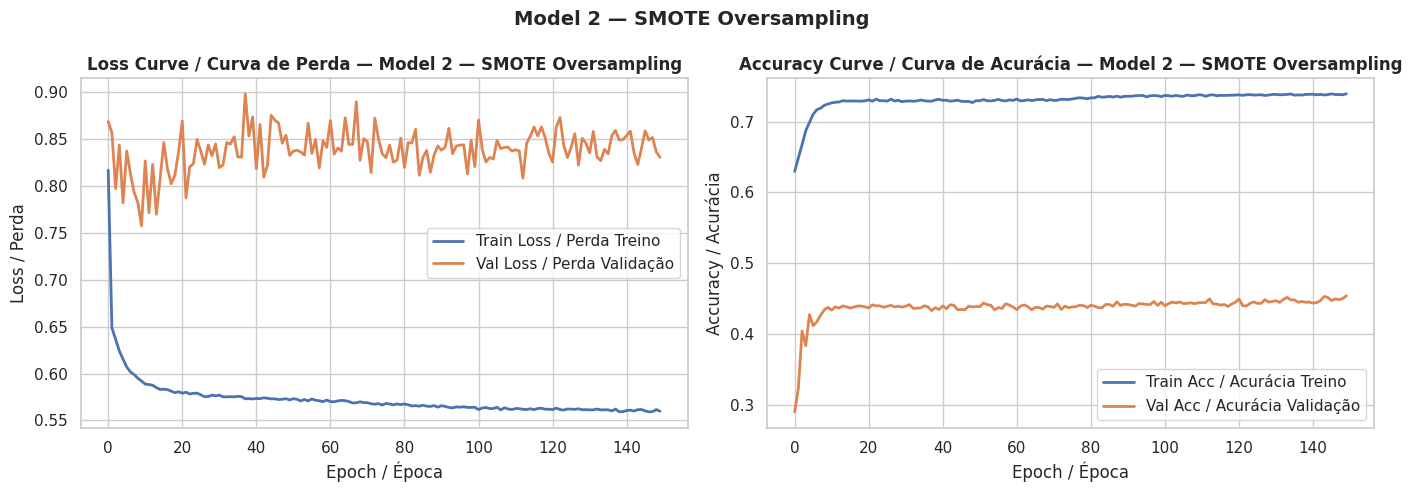

In [29]:
"""
Train neural network model 2 — SMOTE dataset.
Treina modelo de rede neural 2 — dataset SMOTE.
"""

# TRAIN SMOTE MODEL / TREINA MODELO SMOTE
history_smote = model_smote.fit(
    X_smote, y_smote,
    validation_split=0.2,
    batch_size=50,
    epochs=150,
    shuffle=True,
    verbose=1)

# EVALUATE ON TRAIN / AVALIA NO TREINO
train_loss_smote, train_acc_smote = model_smote.evaluate(X_smote, y_smote, verbose=0)
print(f"\nTrain Loss / Perda treino:        {train_loss_smote:.4f}")
print(f"Train Accuracy / Acurácia treino: {train_acc_smote:.4f}")

plot_training_history(history_smote, "Model 2 — SMOTE Oversampling")

Confusion matrix / Matriz de confusão
[[3042  312]
 [ 512  454]]


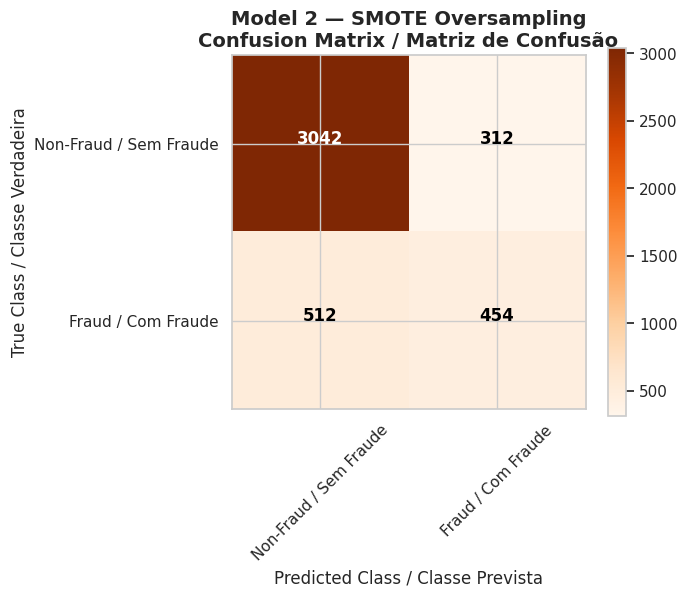

In [30]:
"""
Evaluate model 2 — predictions and confusion matrix on SMOTE dataset.
Avalia modelo 2 — predições e matriz de confusão no dataset SMOTE.
"""

# PREDICTIONS SMOTE MODEL / PREDIÇÕES MODELO SMOTE
y_pred_smote = np.argmax(model_smote.predict(X_test, batch_size=50, verbose=0), axis=1)
cm_smote     = confusion_matrix(y_test, y_pred_smote)

plot_confusion_matrix(
    cm_smote,
    labels,
    title="Model 2 — SMOTE Oversampling\nConfusion Matrix / Matriz de Confusão",
    cmap=plt.cm.Oranges
)

In [31]:
print(classification_report(y_test, y_pred_smote, target_names=labels))

                        precision    recall  f1-score   support

Non-Fraud / Sem Fraude       0.86      0.91      0.88      3354
    Fraud / Com Fraude       0.59      0.47      0.52       966

              accuracy                           0.81      4320
             macro avg       0.72      0.69      0.70      4320
          weighted avg       0.80      0.81      0.80      4320



In [32]:
"""
Final comparison — undersampling vs SMOTE neural network models.
Comparação final — modelos de rede neural subamostragem vs SMOTE.
"""

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# COMPUTE METRICS / CALCULA MÉTRICAS
def get_metrics(y_true, y_pred, model_name):
    """Compute all metrics / Calcula todas as métricas."""
    return {
        "Model":     model_name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_true, y_pred, zero_division=0),
    }

comparison_df = pd.DataFrame([
    get_metrics(y_test, y_pred_undersample, "Neural Network — Undersampling"),
    get_metrics(y_test, y_pred_smote,       "Neural Network — SMOTE"),
])

def highlight_best(row):
    """Highlight best model row in gold / Destaca linha do melhor modelo em dourado."""
    if row["Accuracy"] == comparison_df["Accuracy"].max():
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

print("Final Comparison / Comparação Final:\n")
display(
    comparison_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
    })
)

Final Comparison / Comparação Final:



,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network — Undersampling,0.8132,0.6828,0.3075,0.4240
1,Neural Network — SMOTE,0.8093,0.5927,0.4700,0.5242


In [33]:
"""
Save neural network models to disk.
Salva modelos de rede neural em disco.
"""

import os

os.makedirs("models", exist_ok=True)

# SAVE MODELS / SALVA MODELOS
model_undersample.save("models/neural_network_undersampling.h5")
model_smote.save("models/neural_network_smote.h5")

print("Models saved / Modelos salvos:")
print("  models/neural_network_undersampling.h5")
print("  models/neural_network_smote.h5")

Models saved / Modelos salvos:
  models/neural_network_undersampling.h5
  models/neural_network_smote.h5
